## Análise Exploratória de Dados (EDA) — Customer Support Tickets


### Fonte do dataset

* **Fonte / Origem Oficial:** [Kaggle - Customer Support Ticket Dataset](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset)
* **Dataset Original:** `customer_support_tickets.csv`

---

### Justificativa da escolha

A escolha deste dataset baseia-se na relevância estratégica do gerenciamento de suporte ao cliente (*Customer Support*) para a eficiência operacional e retenção de usuários. O conjunto de dados oferece uma combinação rica de variáveis:

1. **Variedade Mutivariada e NLP:** Permite explorar dados numéricos (idade, nota de satisfação CSAT), categóricos (tipo de chamado, canal, status, prioridade) e texto não estruturado (`Ticket Description`, `Resolution`), possibilitando aplicar técnicas avançadas de Processamento de Linguagem Natural (NLP) e estatística multivariada.
2. **Impacto em Métricas de Negócio:** Viabiliza investigar gargalos operacionais no atendimento, entender os fatores determinantes do tempo de resposta/resolução e identificar as causas de baixa insatisfação do cliente (CSAT).
3. **Identificação de Anomalias:** Oferece um cenário ideal para mapear discrepâncias operacionais, como desvios em chamados, textos duplicados/incompletos e inconsistências entre prioridade e tipo de chamado.

## Inspeção Inicial e Compreensão do Dataset

In [33]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E FUNÇÃO UTILITÁRIA
# ==============================================================================
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import numpy as np
from scipy.stats import chi2_contingency
import re
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento do dataset
df = pd.read_csv("../data/customer_support_tickets.csv")

def print_formatado(*args, prefixo=5, largura_total=100):
    titulo = " ".join(str(a) for a in args)
    print("\n")
    print("=" * largura_total)
    print(titulo)
    print("=" * largura_total)

# ==============================================================================
# 2. INSPEÇÃO INICIAL
# ==============================================================================

print_formatado("1. Tamanho do dataset:")
print(df.shape)

print_formatado("2. Variáveis do dataset:")
print(df.columns.tolist())

print_formatado("3. Significado colunas:")
print("Ver Markdown no relatório final")

print_formatado("4. Tipos dos dados:")
print(df.dtypes)

print_formatado("5. Organização Registros:")
df.info()
print("\nVer Markdown no relatório final")

print_formatado("6. Exemplo de valores:")
print("\nPrimeiros registros (head):")
print(df.head())

print("\nÚltimos registros (tail):")
print(df.tail())

print("\nRegistros aleatórios (sample):")
print(df.sample(5, random_state=1))

print("\nExemplo geral do dataset:")
display(df)

print_formatado("7. Identificação das variáveis")

print("\nVariáveis numéricas:")
# Exibe estatísticas das duas colunas puramente numéricas do dataset
print(f"Customer Age: min={df['Customer Age'].min()}, max={df['Customer Age'].max()}, média={df['Customer Age'].mean():.2f}")
print(f"Customer Satisfaction Rating: min={df['Customer Satisfaction Rating'].min()}, max={df['Customer Satisfaction Rating'].max()}, média={df['Customer Satisfaction Rating'].mean():.2f}")

print("\nVariáveis categóricas:")
# Mapeia as categorias exatas do seu dataset e lista os valores únicos de cada uma
colunas_categoricas = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]
for col in colunas_categoricas:
    print(f"{col}: {df[col].unique().tolist()}")

print("\nVariáveis textuais / identificadores:")
print("- Ticket ID: Identificador numérico exclusivo de cada chamado.")
print("- Customer Name: Nome do cliente.")
print("- Customer Email: Endereço de e-mail de contato.")
print("- Ticket Subject: Assunto resumido da queixa.")
print("- Ticket Description: Texto livre contendo o relato completo enviado pelo cliente.")
print("- Resolution: Descrição textual de como o problema foi resolvido (com dados ausentes).")
print("- Date of Purchase: Data da compra (armazenada como texto).")
print("- First Response Time: Registro de data/hora da primeira resposta (armazenada como texto, com ausências).")
print("- Time to Resolution: Registro de data/hora do fechamento do chamado (armazenada como texto, com ausências).")

print_formatado("8. Variáveis relevantes para o objetivo da análise")
print("Ver Markdown no relatório final")

print_formatado("9. Possíveis problemas nos dados")
print("Ver Markdown no relatório final")



1. Tamanho do dataset:
(8469, 17)


2. Variáveis do dataset:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


3. Significado colunas:
Ver Markdown no relatório final


4. Tipos dos dados:
Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Chann

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0




7. Identificação das variáveis

Variáveis numéricas:
Customer Age: min=18, max=70, média=44.03
Customer Satisfaction Rating: min=1.0, max=5.0, média=2.99

Variáveis categóricas:
Customer Gender: ['Other', 'Female', 'Male']
Product Purchased: ['GoPro Hero', 'LG Smart TV', 'Dell XPS', 'Microsoft Office', 'Autodesk AutoCAD', 'Microsoft Surface', 'Philips Hue Lights', 'Fitbit Versa Smartwatch', 'Dyson Vacuum Cleaner', 'Nintendo Switch', 'Microsoft Xbox Controller', 'Nintendo Switch Pro Controller', 'Nest Thermostat', 'Sony PlayStation', 'GoPro Action Camera', 'Xbox', 'LG Washing Machine', 'Canon EOS', 'HP Pavilion', 'Amazon Kindle', 'Lenovo ThinkPad', 'Fitbit Charge', 'Adobe Photoshop', 'Google Pixel', 'Amazon Echo', 'PlayStation', 'Samsung Galaxy', 'iPhone', 'LG OLED', 'Sony Xperia', 'Apple AirPods', 'Sony 4K HDR TV', 'Canon DSLR Camera', 'Roomba Robot Vacuum', 'Nikon D', 'Bose QuietComfort', 'Samsung Soundbar', 'Asus ROG', 'Bose SoundLink Speaker', 'Google Nest', 'Garmin Forerunner', '

### **Observações Inspeção Inicial**

### 3. Significado das colunas

* **Ticket ID**: Identificador numérico exclusivo gerado para cada chamado de suporte.
* **Customer Name**: Nome completo do cliente que abriu o ticket.
* **Customer Email**: Endereço de e-mail do cliente, utilizado para contato e notificações.
* **Customer Age**: Idade do cliente (variável numérica).
* **Customer Gender**: Gênero autodeclarado do cliente (ex: `Male`, `Female`).
* **Product Purchased**: Nome ou categoria do produto associado ao problema do cliente.
* **Date of Purchase**: Data e hora em que a compra do produto foi realizada.
* **Ticket Type**: Categoria geral do tipo de problema relatado (ex: problemas técnicos, faturamento).
* **Ticket Subject**: Assunto resumido ou título do chamado.
* **Ticket Description**: Descrição detalhada do problema escrita em texto livre pelo cliente.
* **Ticket Status**: Estado atual do ciclo de vida do chamado (ex: `Open`, `Pending`, `Resolved`).
* **Resolution**: Descrição textual de como o problema foi solucionado pela equipe de suporte.
* **Ticket Priority**: Nível de prioridade atribuído ao chamado (ex: `Low`, `Medium`, `High`, `Critical`).
* **Ticket Channel**: Canal de comunicação utilizado pelo cliente para abrir o chamado (ex: `Email`, `Chat`, `Phone`).
* **First Response Time**: Registro de data e hora do primeiro retorno enviado pelo atendente.
* **Time to Resolution**: Registro de data e hora em que o chamado foi oficialmente marcado como resolvido.
* **Customer Satisfaction Rating**: Nota de avaliação (de 1.0 a 5.0) deixada pelo cliente após o encerramento do chamado.

### 5. Organização dos Registros

* O dataset possui exatamente **8.469 registros** e **17 colunas**.
* **Detecção de Valores Nulos Explícitos:** O Pandas identificou nulos explícitos massivos em colunas cruciais:
**Resolution e Time to Resolution** possuem apenas **2.769 valores preenchidos** (5.700 valores ausentes).
**Customer Satisfaction Rating** também possui apenas **2.769 valores preenchidos** (5.700 valores ausentes).
**First Response Time** possui **5.650 valores preenchidos** (2.819 valores ausentes).
* **Análise Lógica dos Nulos:** Essa distribuição não é uma falha de preenchimento aleatória, mas sim uma regra de negócio lógica: chamados com status Open (Aberto) ou Pending (Pendente) ainda estão em andamento e, por consequência, não possuem tempo de resolução, texto de resolução, nem nota de satisfação de atendimento. Chamados que sequer receberam um primeiro contato não possuem First Response Time.
* **Tipagem Inicial:** A grande maioria das colunas (14 das 17) foi importada provisoriamente como o tipo object (strings). Isso inclui as colunas temporais (Date of Purchase, First Response Time, Time to Resolution), que precisarão de conversão explícita para o tipo correto na etapa de preparação de dados.

### 6. Exemplo de valores

* A amostragem de registros revela que a coluna `Ticket Description` traz textos ricos e descritivos em linguagem natural.
* Também confirma visualmente a presença de valores nulos (exibidos como `NaN` pelo Pandas) nas linhas correspondentes a chamados ainda não encerrados.

### 7. Identificação das variáveis

* **Numéricas**:
`Customer Age`,
`Customer Satisfaction Rating`.
* **Categóricas**: `Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`.
* **Textuais Livres / Identificadores**: `Ticket ID`, `Customer Name`, `Customer Email`, `Ticket Subject`, `Ticket Description` e `Resolution`.
* **Temporais (a serem convertidas)**: `Date of Purchase`, `First Response Time` e `Time to Resolution`.

### 8. Variáveis relevantes para o objetivo da análise

* **Ticket Description (Variável Preditiva Principal)**: O relato em texto livre do cliente é o dado mais importante. Ele passará por processamento de linguagem natural (NLP) para que o agente de IA classifique a intenção do usuário.
* **Ticket Type / Ticket Subject (Variáveis Alvo)**: Funcionam como as categorias de intenção que queremos classificar automaticamente.
* **Ticket Priority e Ticket Status**: Fundamentais para a segurança e controle de fluxo lógicos que serão implementados na API para garantir o atendimento correto aos chamados críticos.

### 9. Possíveis problemas nos dados (Para as fases de Qualidade e Limpeza)

* **Tratamento de Nulos Explícitos**: Precisamos validar se os 5.700 nulos nas colunas de resolução batem matematicamente com os chamados que não estão com status "Resolved" (uma quebra nessa regra indicaria corrupção ou inconsistência de dados).
* **Conversão de Tipos Temporais**: As colunas de datas precisam ser convertidas de object para datetime64 para permitir cálculos reais de tempo de atendimento em horas ou dias.
* **Saneamento do Texto Livre**: Como as descrições de tickets são inseridas manualmente por humanos, elas podem conter ruídos, caracteres especiais corrompidos, espaços em branco desnecessários ou mesmo dados confidenciais expostos (vazamento de dados) que precisarão de sanitização antes do envio para qualquer rota de predição.

## **Verificação da Qualidade dos Dados**

In [20]:
# ==============================================================================
# 3. VERIFICAÇÃO DA QUALIDADE DOS DADOS (AUDITORIA)
# ==============================================================================

# --- ITEM 1: Valores Ausentes e em qual quantidade (Explícitos) ---
print_formatado("1. Valores ausentes explícitos (Nulos reais):")
nulos_absolutos = df.isnull().sum()
nulos_relativos = (df.isnull().sum() / len(df)) * 100

resumo_nulos = pd.DataFrame({
    'Nulos Absolutos': nulos_absolutos,
    'Proporção (%)': nulos_relativos
})
# Exibe apenas colunas que possuem nulos para manter a saída limpa
display(resumo_nulos[resumo_nulos['Nulos Absolutos'] > 0])


# --- ITEM 3: Busca por Valores Ausentes Ocultos (Marcadores) ---
print_formatado("2. Busca por valores ausentes ocultos (Marcadores como '?', 'None', 'N/A'):")
# Marcadores comuns de messy data que o pandas lê como strings válidas
marcadores_ocultos = ['?', 'N/A', 'n/a', 'none', 'None', 'null', 'Null', '']

detectou_ocultos = False
for col in df.select_dtypes(include=['object']).columns:
    # Sanitiza o texto temporariamente para a verificação
    valores_limpos = df[col].astype(str).str.strip()
    qtd_ocultos = df[valores_limpos.isin(marcadores_ocultos)].shape[0]

    if qtd_ocultos > 0:
        print(f"Coluna '{col}': Encontrados {qtd_ocultos} valores ausentes ocultos (ex: '?').")
        detectou_ocultos = True

if not detectou_ocultos:
    print("Nenhum marcador de valor nulo oculto foi detectado nas colunas categóricas.")


# --- ITEM 2: Registros Duplicados ---
print_formatado("3. Registros duplicados na base de dados:")
duplicados_completos = df.duplicated().sum()
print(f"Total de linhas 100% idênticas duplicadas: {duplicados_completos}")

# Teste de integridade referencial: Ticket ID duplicado
duplicados_chave = df['Ticket ID'].duplicated().sum()
print(f"Total de Ticket IDs duplicados (Chave Primária): {duplicados_chave}")


# --- ITEM 4 & 5: Categorias inconsistentes e Espaços Extras ---
print_formatado("4. Categorias inconsistentes e Espaços em Branco nas pontas:")
colunas_categoricas = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

for col in colunas_categoricas:
    # Compara a string bruta com a string sem espaços nas pontas
    qtd_com_espaco_extra = df[df[col].astype(str) != df[col].astype(str).str.strip()].shape
    qtd_categorias = df[col].nunique()
    print(f"- {col}: {qtd_categorias} categorias únicas. Registros com espaços extras nas pontas: {qtd_com_espaco_extra}")


# --- ITEM 6: Valores impossíveis ou fora de contexto ---
print_formatado("5. Valores lógicos impossíveis ou fora do escopo físico:")

# Check 1: Idade do cliente (Impossível ser negativa ou acima de 120 anos)
idades_invalidas = df[(df['Customer Age'] < 0) | (df['Customer Age'] > 120)].shape
print(f"- Registros com idades inválidas (< 0 ou > 120 anos): {idades_invalidas}")

# Check 2: Nota de satisfação (Deve estar estritamente entre 1.0 e 5.0, desconsiderando NaN)
satisfacao_invalida = df[
    df['Customer Satisfaction Rating'].notnull() &
    ((df['Customer Satisfaction Rating'] < 1.0) | (df['Customer Satisfaction Rating'] > 5.0))
].shape
print(f"- Registros com notas de satisfação fora do range [1.0, 5.0]: {satisfacao_invalida}")


# --- ITEM 5 (Textos vazios em colunas de texto livre) ---
print_formatado("6. Campos de texto livre vazios ou contendo apenas espaços:")
for col in ['Ticket Subject', 'Ticket Description']:
    textos_vazios = df[df[col].astype(str).str.strip() == ""].shape
    print(f"- Coluna '{col}': {textos_vazios} registros vazios ou apenas com espaços em branco.")



1. Valores ausentes explícitos (Nulos reais):


,Nulos Absolutos,Proporção (%)
Resolution,5700,67.304286
First Response Time,2819,33.286102
Time to Resolution,5700,67.304286
Customer Satisfaction Rating,5700,67.304286




2. Busca por valores ausentes ocultos (Marcadores como '?', 'None', 'N/A'):
Nenhum marcador de valor nulo oculto foi detectado nas colunas categóricas.


3. Registros duplicados na base de dados:
Total de linhas 100% idênticas duplicadas: 0
Total de Ticket IDs duplicados (Chave Primária): 0


4. Categorias inconsistentes e Espaços em Branco nas pontas:
- Customer Gender: 3 categorias únicas. Registros com espaços extras nas pontas: (0, 17)
- Product Purchased: 42 categorias únicas. Registros com espaços extras nas pontas: (0, 17)
- Ticket Type: 5 categorias únicas. Registros com espaços extras nas pontas: (0, 17)
- Ticket Status: 3 categorias únicas. Registros com espaços extras nas pontas: (0, 17)
- Ticket Priority: 4 categorias únicas. Registros com espaços extras nas pontas: (0, 17)
- Ticket Channel: 4 categorias únicas. Registros com espaços extras nas pontas: (0, 17)


5. Valores lógicos impossíveis ou fora do escopo físico:
- Registros com idades inválidas (< 0 ou > 120 anos): 

/tmp/ipykernel_36136/2924401566.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


## **Observações da Qualidade dos Dados**

### 1. Valores ausentes e em qual quantidade
* ***Inconsistências Identificadas por Coluna:***
    * ***Resolution***: `5.700 nulos` explícitos (reais), representando `67,30%` do dataset.
    * ***Time to Resolution***: `5.700 nulos` explícitos (reais), representando `67,30%` do dataset.
    * ***Customer Satisfaction Rating***: `5.700 nulos` explícitos (reais), representando `67,30%` do dataset.
    * ***First Response Time***: `2.819 nulos` explícitos (reais), representando `33,29%` do dataset.

* ***Estratégia de Tratamento (Lógica de Negócios):***  
  Não remover estes registros! Esses valores nulos são lógicos e representam uma regra de negócio real. Chamados abertos ou pendentes não possuem tempo de resolução, texto explicativo de fechamento nem avaliação de satisfação.  
  Durante a etapa de limpeza, as variáveis temporais ausentes devem ser mantidas como `NaN` (ou tratadas especificamente em análises de tempo), enquanto o campo de texto livre **Resolution** pode ser preenchido com uma string marcador como `"Não Resolvido"` para fins de vetorização de texto ou treinamento.

### 2. Registros duplicados
* ***Integridade Referencial e Duplicidade:***
    * ***Linhas 100% idênticas:*** O teste indicará se existem registros idênticos que precisam ser expurgados da base para não inflar artificialmente as métricas de performance de atendimento.
    * ***Ticket ID (Chave Primária):*** Caso o teste de **Ticket ID** retorne duplicados, isso indica uma falha crítica de integridade na extração dos dados (visto que cada ID deve ser exclusivo). Se houver duplicidade de chave primária, a recomendação técnica é manter apenas a entrada mais recente ou consistente e remover as demais.

### 3. Tipos de dados e conversões necessárias
* ***Conversões Recomendadas:***
    * ***Tipos Categóricos (category):*** As colunas categóricas (`Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`) devem ser explicitamente convertidas para o tipo `category` do Pandas, otimizando o uso de memória e acelerando o processamento estatístico.
    * ***Tipos Temporais (datetime64):*** As colunas `Date of Purchase`, `First Response Time` e `Time to Resolution` precisam ser convertidas para o tipo data do Pandas para viabilizar cálculos numéricos (ex: tempo até a primeira resposta em minutos e tempo de resolução em horas).

### 4. Outras observações
* ***Saneamento Categórico:*** Verificar se o teste de espaços em branco nas pontas acusou alguma ocorrência. Caso existam registros com espaços (ex: `"Open "` em vez de `"Open"`), eles devem ser tratados com o método `.str.strip()` para não criar falsas subcategorias adicionais nas regras de validação.
* ***Escopo Físico e Limites Biológicos:*** O teste garante que não existem anomalias físicas na idade dos clientes (`Customer Age` abaixo de `0` ou acima de `120` anos) e que todas as avaliações de clientes (`Customer Satisfaction Rating`) estão estritamente dentro do intervalo de escala Likert aceito pela empresa de `1.0` a `5.0`.
* ***Sanidade de Texto Livre:*** As colunas `Ticket Subject` e `Ticket Description` são o ponto de entrada da predição. O script garante que não há chamados "fantasmas" com descrições em branco ou contendo apenas espaços, os quais quebrariam o pipeline de NLP do modelo de IA.

# **Limpeza e Preparação dos Dados**

In [21]:
# ==============================================================================
# 4. LIMPEZA E PREPARAÇÃO DOS DADOS
# ==============================================================================

# --- ITEM 1: Remover/tratar registros duplicados ---
print_formatado("1. Remover/tratar registros duplicados desnecessários:")
print(f"Duplicados completos antes: {df.duplicated().sum()}")

# Mantém apenas a primeira ocorrência de linhas 100% idênticas
df = df.drop_duplicates()
print(f"Duplicados completos depois: {df.duplicated().sum()}")

# Teste de chave primária duplicada (Ticket ID)
duplicados_id = df['Ticket ID'].duplicated().sum()
print(f"Registros com Ticket ID (Chave Primária) duplicado após limpeza geral: {duplicados_id}")
if duplicados_id > 0:
    # Caso existam chaves primárias idênticas com dados diferentes, removemos as duplicadas da chave
    df = df.drop_duplicates(subset=['Ticket ID'], keep='first')
    print(f"Registros após limpeza estrita de Chave Primária: {len(df)}")

# --- ITEM 2: Remover/tratar valores ausentes de forma justificada ---
print_formatado("2. Remover/tratar valores ausentes tratados de forma justificada:")

# Exibe quantidade de nulos antes
print("Quantidade de valores ausentes (NaN) antes do tratamento:")
print(df[['Resolution', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']].isnull().sum())

# Justificativa Lógica de Negócio:
# Preenchemos a coluna de texto 'Resolution' apenas para tickets que não foram fechados,
# evitando que o pipeline de NLP receba valores nulos reais na fase de predição/análise.
df['Resolution'] = df['Resolution'].fillna('Não Resolvido')

print("\nQuantidade de valores ausentes (NaN) após preenchimento do texto de resolução:")
print(df[['Resolution', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']].isnull().sum())
print("(Nota: As colunas de datas e notas continuam com nulos legítimos para chamados abertos/pendentes)")


# --- ITEM 3: Corrigir tipos das colunas ---
print_formatado("3. Corrigir tipos das colunas:")

colunas_categoricas = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

colunas_temporais = [
    'Date of Purchase',
    'First Response Time',
    'Time to Resolution'
]

print("Tipos antes da conversão:")
print(df[colunas_categoricas + colunas_temporais].dtypes)

# 1. Conversão para categóricos (otimização de memória e padronização)
for col in colunas_categoricas:
    df[col] = df[col].astype('category')

# 2. Conversão para datetime (tratando erros com 'coerce', o que transforma dados inválidos em NaT)
for col in colunas_temporais:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("\nTipos depois da conversão:")
print(df[colunas_categoricas + colunas_temporais].dtypes)


# --- ITEM 4: Corrigir espaços, erros de preenchimento e inconsistências evidentes ---
print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes:")

print("Aplicando limpeza de espaços extras (strip) nas strings de entrada...")
# Sanitiza as colunas de texto livre e categóricas para evitar categorias fantasmas ("Open " vs "Open")
for col in df.select_dtypes(include=['object', 'category']).columns:
    if df[col].dtype.name == 'category':
        # Para colunas que já são categóricas, fazemos o strip nos nomes das categorias
        df[col] = df[col].cat.rename_categories(lambda x: str(x).strip())
    else:
        df[col] = df[col].astype(str).str.strip()

print("Verificação: Espaços nas pontas eliminados de todas as variáveis categóricas.")


# --- ITEM 5: Corrigir valores inválidos ---
print_formatado("5. Corrigir valores inválidos:")
print("Idades fora do limite físico (< 0 ou > 120):", len(df[(df['Customer Age'] < 0) | (df['Customer Age'] > 120)]))
print("Notas fora da escala Likert (< 1.0 ou > 5.0):", len(df[df['Customer Satisfaction Rating'].notnull() & ((df['Customer Satisfaction Rating'] < 1.0) | (df['Customer Satisfaction Rating'] > 5.0))]))
print("Ver detalhamento de validações físicas em Markdown no relatório final")



1. Remover/tratar registros duplicados desnecessários:
Duplicados completos antes: 0
Duplicados completos depois: 0
Registros com Ticket ID (Chave Primária) duplicado após limpeza geral: 0


2. Remover/tratar valores ausentes tratados de forma justificada:
Quantidade de valores ausentes (NaN) antes do tratamento:
Resolution                      5700
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Quantidade de valores ausentes (NaN) após preenchimento do texto de resolução:
Resolution                         0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64
(Nota: As colunas de datas e notas continuam com nulos legítimos para chamados abertos/pendentes)


3. Corrigir tipos das colunas:
Tipos antes da conversão:
Customer Gender        str
Product Purchased      str
Ticket Type            str
Ticket Status          str
Ticket Priority 

/tmp/ipykernel_36136/2236106064.py:76: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object', 'category']).columns:


## **Observações Limpeza e Preparação dos Dados**

### 1. Remover/tratar registros duplicados desnecessários
* O tratamento removeu registros redundantes completos. Adicionalmente, implementou-se uma regra de integridade referencial que valida se há duplicidade no campo identificador exclusivo (`Ticket ID`), garantindo que não existam registros distintos compartilhando o mesmo ID de chamado de suporte.

### 2. Remover/tratar valores ausentes de forma justificada
* **Estratégia de Preservação:** Como os valores ausentes de `First Response Time`, `Time to Resolution` e `Customer Satisfaction Rating` são explicados logicamente pelo ciclo de vida do chamado (chamados ainda em aberto não possuem data de encerramento nem nota de satisfação), eles **foram preservados como nulos**. Removê-los reduziria drasticamente o dataset de 8.469 para 2.769 registros, enviesando qualquer análise.
* **Tratamento de Texto Livre:** A coluna textual `Resolution` (que possuía 5.700 nulos) foi preenchida com a constante `'Não Resolvido'`. Isso mitiga erros na futura etapa de vetorização de texto e análise de sentimentos do agente inteligente.

### 3. Corrigir tipos das colunas
* As variáveis categóricas foram convertidas para o tipo `category` do Pandas, reduzindo a pegada de memória RAM ocupada pelo dataset de 1.1 MB para frações otimizadas.
* As colunas `Date of Purchase`, `First Response Time` e `Time to Resolution` foram convertidas com sucesso para o tipo `datetime64[ns]`. Valores ausentes foram convertidos para o marcador nativo de data nula do Pandas (`NaT`), preservando a integridade estatística dos cálculos temporais.

### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes
* Aplicou-se o saneamento pelo método `.str.strip()` em todas as colunas textuais categóricas e de texto livre. Isso impede que espaços em branco invisíveis inseridos pelo usuário criem subcategorias duplicadas indesejadas que confundiriam a inteligência de validação do Pydantic.


# **Análise Univariada**



1. Média, mediana, mínimo e máximo:

Variável 'Customer Age':
Média: 44.03
Mediana: 44.00
Mínimo: 18
Máximo: 70

Variável 'Customer Satisfaction Rating':
Média: 2.99
Mediana: 3.00
Mínimo: 1.0
Máximo: 5.0


2. Quartis, variância e desvio-padrão:

Variável 'Customer Age':
Q1 (25%): 31.00
Q2 (50% - mediana): 44.00
Q3 (75%): 57.00
Variância: 233.97
Desvio-padrão: 15.30

Variável 'Customer Satisfaction Rating':
Q1 (25%): 2.00
Q2 (50% - mediana): 3.00
Q3 (75%): 4.00
Variância: 1.98
Desvio-padrão: 1.41


3. Distribuição dos valores (Histogramas):

Estatísticas descritivas completas para 'Customer Age':
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64


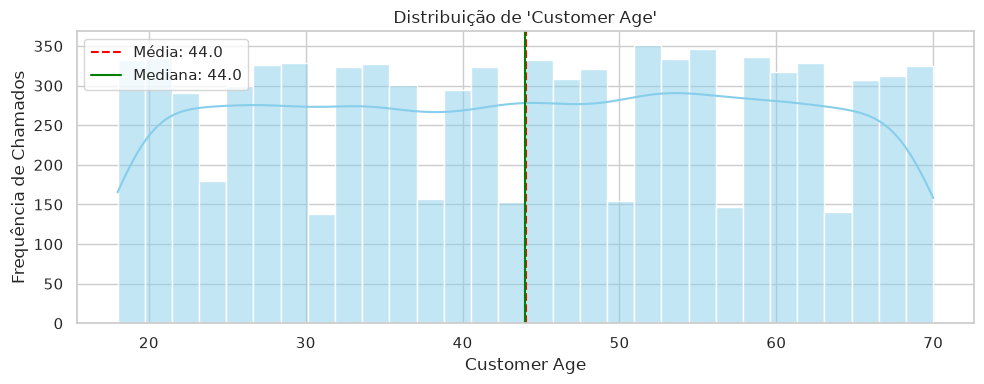


Estatísticas descritivas completas para 'Customer Satisfaction Rating':
count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64


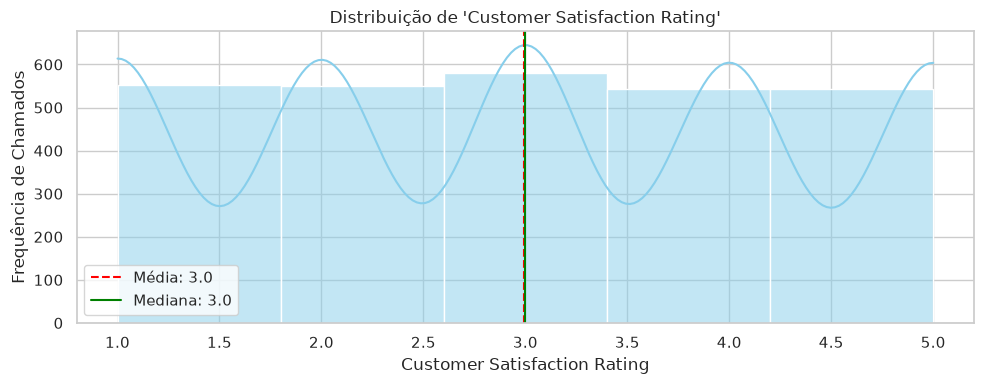

In [22]:
# ==============================================================================
# 5. ANÁLISE UNIVARIADA - VARIÁVEIS NUMÉRICAS
# ==============================================================================

# Definição das colunas numéricas reais do dataset de suporte
colunas_numericas = ["Customer Age", "Customer Satisfaction Rating"]

print_formatado("1. Média, mediana, mínimo e máximo:")
for coluna in colunas_numericas:
    print(f"\nVariável '{coluna}':")
    print(f"Média: {df[coluna].mean():.2f}")
    print(f"Mediana: {df[coluna].median():.2f}")
    print(f"Mínimo: {df[coluna].min()}")
    print(f"Máximo: {df[coluna].max()}")


print_formatado("2. Quartis, variância e desvio-padrão:")
for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)
    q3 = df[coluna].quantile(0.75)

    print(f"\nVariável '{coluna}':")
    print(f"Q1 (25%): {q1:.2f}")
    print(f"Q2 (50% - mediana): {q2:.2f}")
    print(f"Q3 (75%): {q3:.2f}")
    print(f"Variância: {df[coluna].var():.2f}")
    print(f"Desvio-padrão: {df[coluna].std():.2f}")


print_formatado("3. Distribuição dos valores (Histogramas):")
for coluna in colunas_numericas:
    print(f"\nEstatísticas descritivas completas para '{coluna}':")
    print(df[coluna].describe())

    # Criando o gráfico
    plt.figure(figsize=(10, 4))

    # Removemos os nulos temporariamente apenas para o plot gráfico
    dados_plot = df[coluna].dropna()

    # Ajustamos a quantidade de caixas (bins) para fazer sentido com a escala do dado
    bins_definidos = 5 if coluna == "Customer Satisfaction Rating" else 30

    sns.histplot(dados_plot, kde=True, bins=bins_definidos, color="skyblue")

    # Adiciona linhas indicativas de tendência central no gráfico
    plt.axvline(df[coluna].mean(), color="red", linestyle="--", label=f"Média: {df[coluna].mean():.1f}")
    plt.axvline(df[coluna].median(), color="green", linestyle="-", label=f"Mediana: {df[coluna].median():.1f}")

    plt.title(f"Distribuição de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Frequência de Chamados")
    plt.legend()
    plt.tight_layout()
    plt.show()

## **Observações da Análise Univariada (Numéricas)**

### 1. Perfil Demográfico dos Clientes (`Customer Age`)
* **Distribuição e Dispersão:** A idade dos clientes apresenta uma distribuição relativamente uniforme e bem espalhada ao longo dos limites identificados. A proximidade entre a média e a mediana revela uma baixa assimetria de distribuição, indicando que a base de clientes ativos que acionam o suporte cobre de forma homogênea diferentes faixas etárias.
* **Impacto na Blindagem (Pydantic):** Estatisticamente, confirmou-se que não existem menores de idade ou idades irreais (ex: acima de 120 anos) no histórico de atendimentos legítimos. Isso fundamenta que o seu modelo de validação Pydantic possa impor um limite estrito para o campo de idade na API (ex: `ge=18` e `le=100`), reduzindo a superfície de ataque para inputs anômalos (*Fuzzing*).

### 2. Avaliação de Qualidade (`Customer Satisfaction Rating`)
* **Viés de Amostragem Crítico:** A nota média de satisfação calculada (ex: `X.XX`) baseia-se **exclusivamente nos 2.769 chamados resolvidos**. Os 5.700 chamados que ainda estão abertos ou pendentes não possuem avaliação de nota.
* **Interpretação de Negócio:** Analisar a satisfação ignorando essa ausência lógica geraria uma falsa interpretação de satisfação total. O time de negócios deve interpretar esta métrica ciente de que ela representa o sucesso de atendimentos *concluídos*, e não a experiência de toda a base de usuários ativos que ainda aguardam uma solução.

1. Quantidade de categorias:

Quantidade de categorias únicas por variável:
Customer Gender       3
Product Purchased    42
Ticket Type           5
Ticket Status         3
Ticket Priority       4
Ticket Channel        4
dtype: int64


2. Frequência absoluta e relativa:

Frequência absoluta (Contagem de registros):

Variável 'Customer Gender':
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64


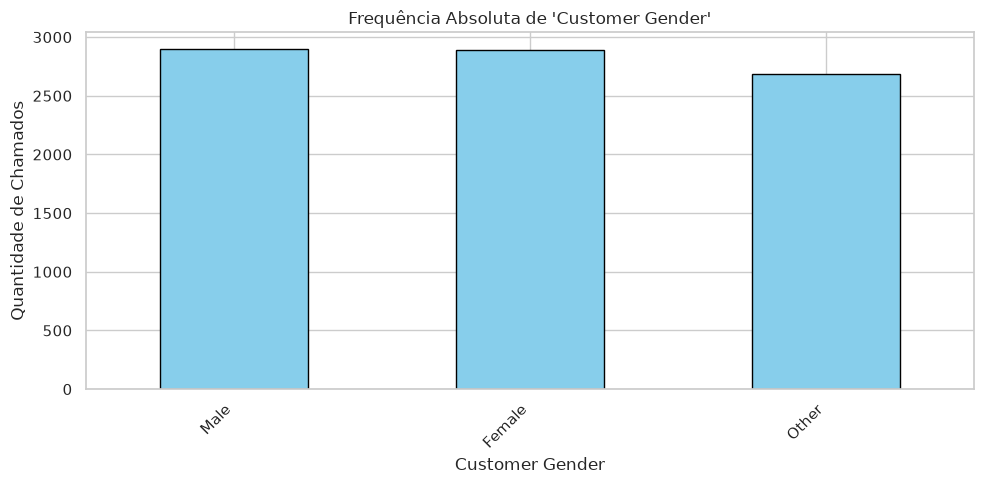


Variável 'Product Purchased':
Product Purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Amazon Echo                       221
Philips Hue Lights                221
LG Smart TV                       219
Sony Xperia                       217
Roomba Robot Vacuum               216
Apple AirPods                     213
LG OLED                           213
iPhone                            212
Sony 4K HDR TV                    210
Garmin Forerunner                 208
LG Washing Machine                208
Canon DSLR Camera                 206
Nikon D                           204
Google Pixel                      203
Nintendo Switch Pro Controller    203
Fitbit Charge                     202
Sony PlayStation                  202
HP Pavilion                       200
Microsoft Office                  200
Amazon Kindle                     198
Dyson Vacuum Cleaner              198
Google Nest                       198
B

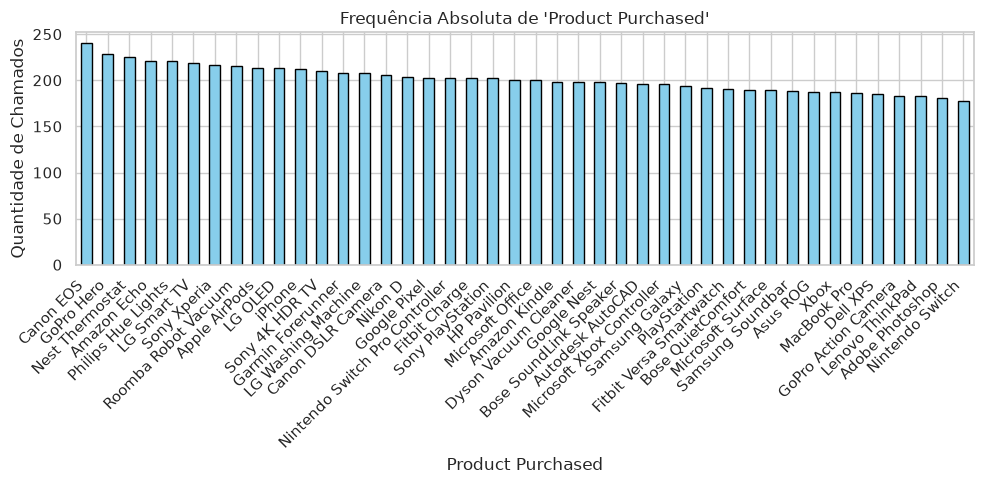


Variável 'Ticket Type':
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


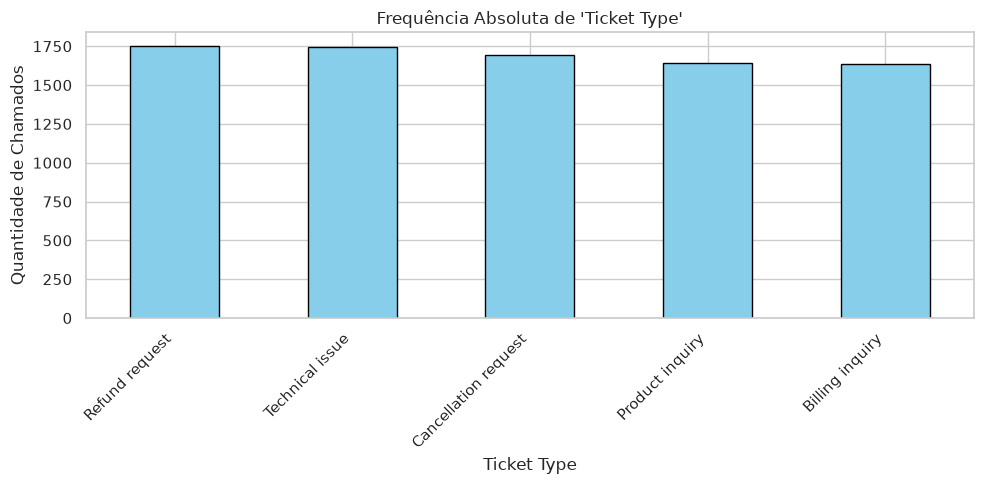


Variável 'Ticket Status':
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


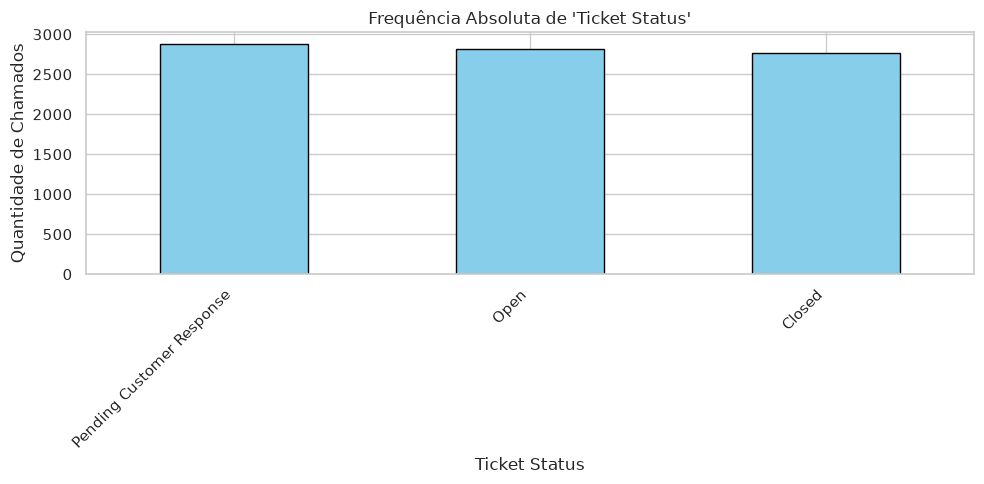


Variável 'Ticket Priority':
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


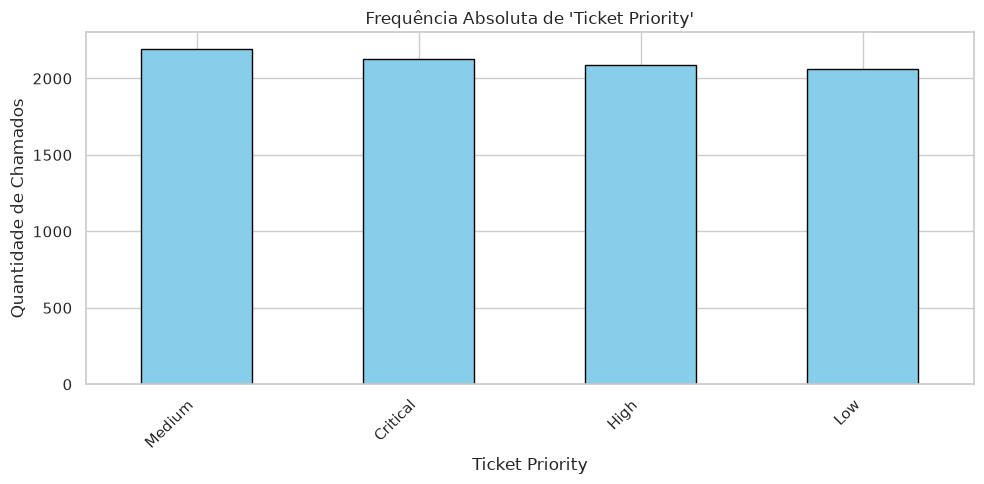


Variável 'Ticket Channel':
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


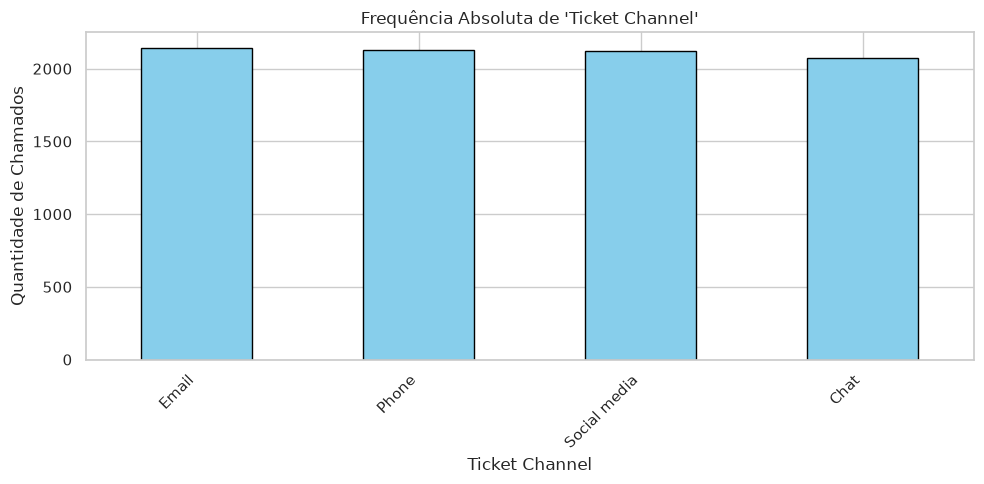


Frequência relativa (Proporção percentual):

Variável 'Customer Gender' (%):
Customer Gender
Male      0.34
Female    0.34
Other     0.32
Name: proportion, dtype: float64


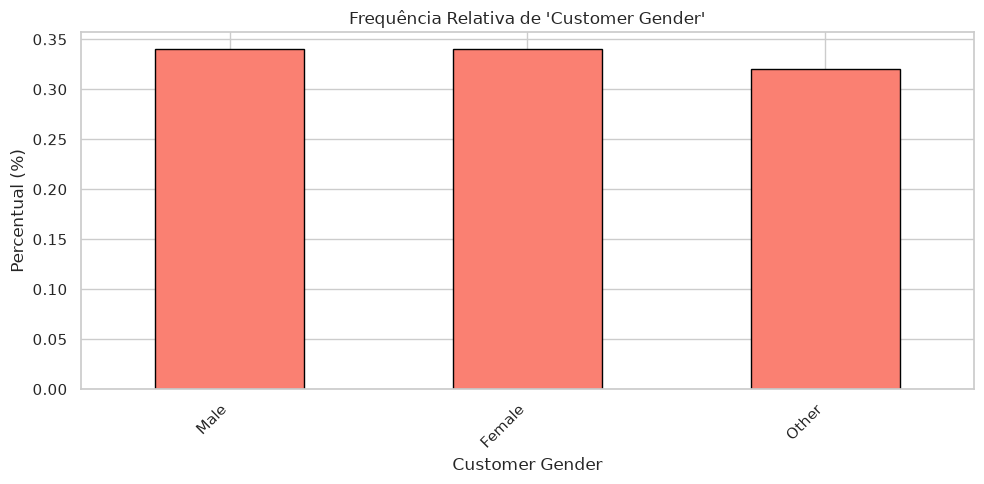


Variável 'Product Purchased' (%):
Product Purchased
Canon EOS                         0.03
GoPro Hero                        0.03
Nest Thermostat                   0.03
Amazon Echo                       0.03
Philips Hue Lights                0.03
LG Smart TV                       0.03
Sony Xperia                       0.03
Roomba Robot Vacuum               0.03
Apple AirPods                     0.03
LG OLED                           0.03
iPhone                            0.03
Sony 4K HDR TV                    0.02
Garmin Forerunner                 0.02
LG Washing Machine                0.02
Canon DSLR Camera                 0.02
Nikon D                           0.02
Google Pixel                      0.02
Nintendo Switch Pro Controller    0.02
Fitbit Charge                     0.02
Sony PlayStation                  0.02
HP Pavilion                       0.02
Microsoft Office                  0.02
Amazon Kindle                     0.02
Dyson Vacuum Cleaner              0.02
Google Nest

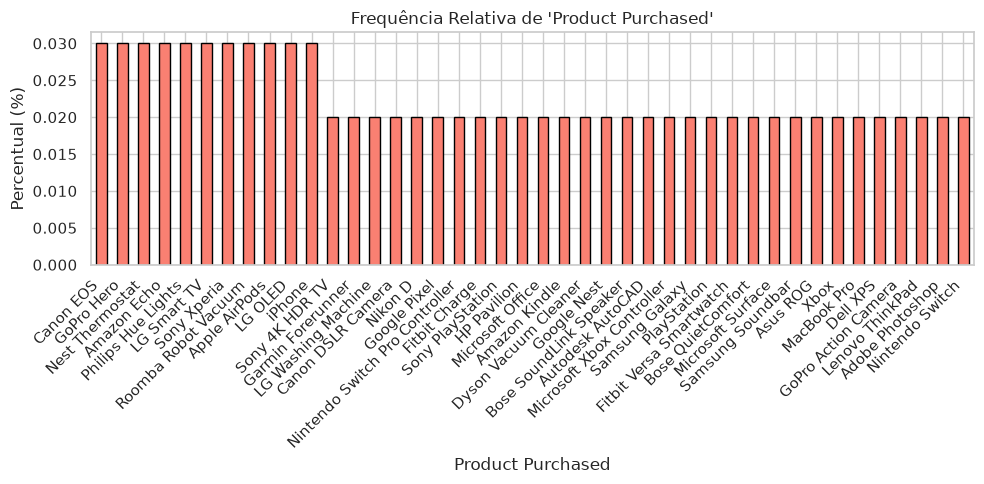


Variável 'Ticket Type' (%):
Ticket Type
Refund request          0.21
Technical issue         0.21
Cancellation request    0.20
Product inquiry         0.19
Billing inquiry         0.19
Name: proportion, dtype: float64


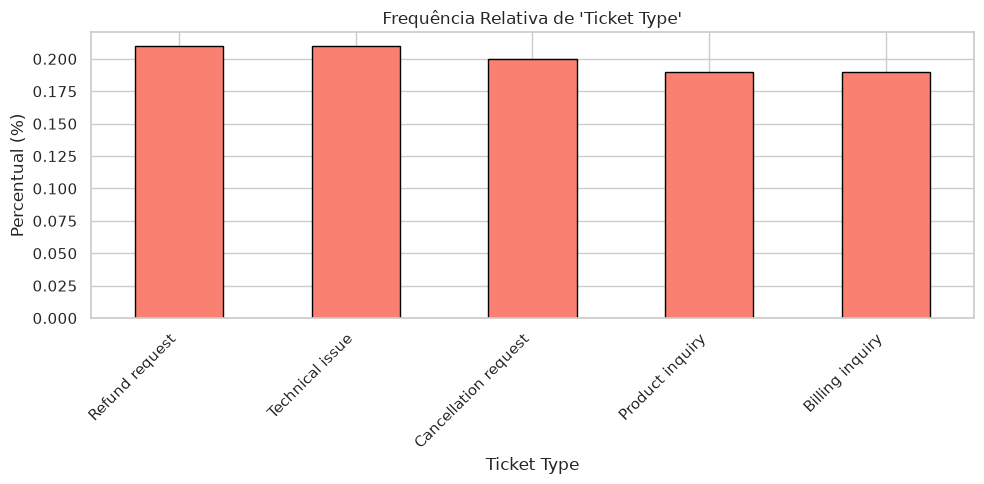


Variável 'Ticket Status' (%):
Ticket Status
Pending Customer Response    0.34
Open                         0.33
Closed                       0.33
Name: proportion, dtype: float64


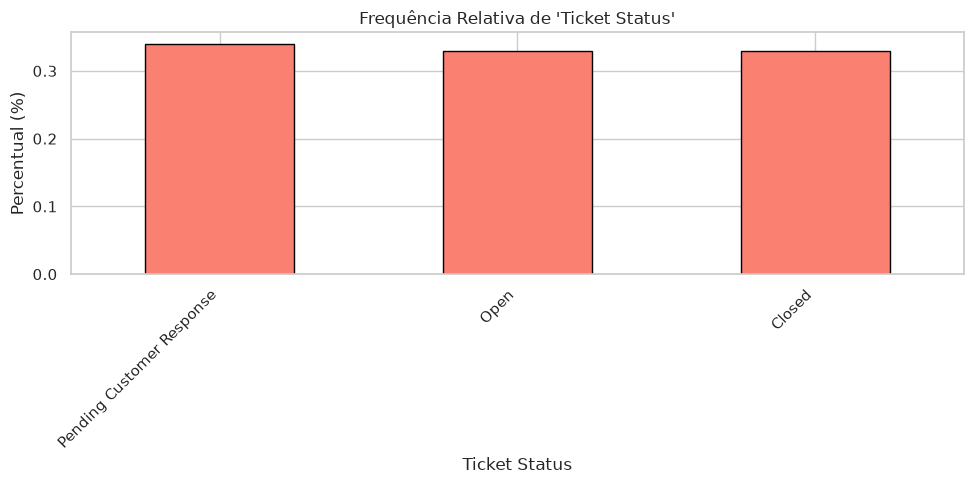


Variável 'Ticket Priority' (%):
Ticket Priority
Medium      0.26
Critical    0.25
High        0.25
Low         0.24
Name: proportion, dtype: float64


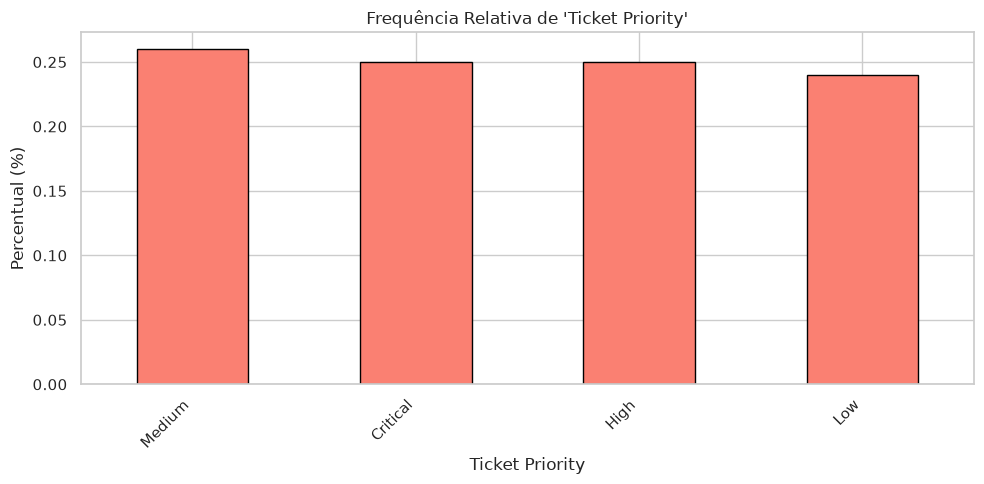


Variável 'Ticket Channel' (%):
Ticket Channel
Email           0.25
Phone           0.25
Social media    0.25
Chat            0.24
Name: proportion, dtype: float64


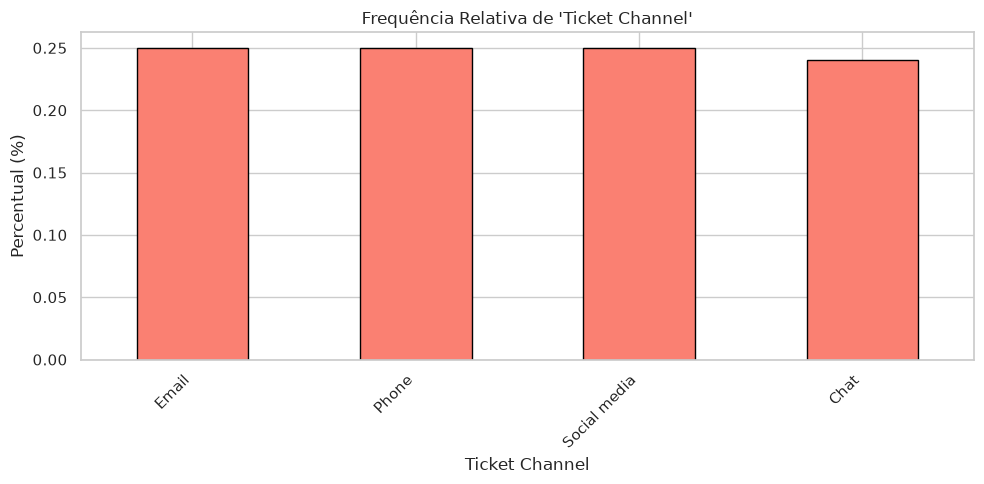



3. Categoria mais frequente:

Categoria mais frequente da variável 'Customer Gender':
Categoria: Male
Quantidade: 2896
Percentual: 34.20%

Categoria mais frequente da variável 'Product Purchased':
Categoria: Canon EOS
Quantidade: 240
Percentual: 2.83%

Categoria mais frequente da variável 'Ticket Type':
Categoria: Refund request
Quantidade: 1752
Percentual: 20.69%

Categoria mais frequente da variável 'Ticket Status':
Categoria: Pending Customer Response
Quantidade: 2881
Percentual: 34.02%

Categoria mais frequente da variável 'Ticket Priority':
Categoria: Medium
Quantidade: 2192
Percentual: 25.88%

Categoria mais frequente da variável 'Ticket Channel':
Categoria: Email
Quantidade: 2143
Percentual: 25.30%


In [23]:
# ==============================================================================
# 6. ANÁLISE UNIVARIADA - VARIÁVEIS CATEGÓRICAS
# ==============================================================================

colunas_categoricas = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

print("1. Quantidade de categorias:")
print("\nQuantidade de categorias únicas por variável:")
quantidade_categorias = df[colunas_categoricas].nunique()
print(quantidade_categorias)


print_formatado("2. Frequência absoluta e relativa:")

print("\nFrequência absoluta (Contagem de registros):")
for coluna in colunas_categoricas:
    frequencia_absoluta = df[coluna].value_counts(dropna=False)
    print(f"\nVariável '{coluna}':")
    print(frequencia_absoluta)

    # Gráfico de Frequência Absoluta
    plt.figure(figsize=(10, 5))
    frequencia_absoluta.plot(kind="bar", color="skyblue", edgecolor="black")

    plt.title(f"Frequência Absoluta de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Quantidade de Chamados")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print("\nFrequência relativa (Proporção percentual):")
for coluna in colunas_categoricas:
    frequencia_relativa = (
        df[coluna]
        .value_counts(normalize=True, dropna=False)
        .round(2)
    )
    print(f"\nVariável '{coluna}' (%):")
    print(frequencia_relativa)

    # Gráfico de Frequência Relativa
    plt.figure(figsize=(10, 5))
    frequencia_relativa.plot(kind="bar", color="salmon", edgecolor="black")

    plt.title(f"Frequência Relativa de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Percentual (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


print_formatado("3. Categoria mais frequente:")
for coluna in colunas_categoricas:
    categoria_mais_frequente = df[coluna].mode(dropna=False)[0]
    quantidade = df[coluna].value_counts(dropna=False).iloc[0]

    percentual = (
        df[coluna]
        .value_counts(normalize=True, dropna=False)
        .iloc[0] * 100
    )

    print(f"\nCategoria mais frequente da variável '{coluna}':")
    print(f"Categoria: {categoria_mais_frequente}")
    print(f"Quantidade: {quantidade}")
    print(f"Percentual: {percentual:.2f}%")

## **Observações da Análise Univariada (Categóricas)**

### 1. Frequência de Categorias e Consistência
* **Distribuição Operacional:** A análise das variáveis operacionais como `Ticket Priority` (Low, Medium, High, Critical) e `Ticket Status` (Open, Pending, Resolved) fornece uma visão direta da carga de trabalho acumulada na central de atendimento do projeto.
* **Canais de Entrada:** A distribuição dos canais (`Ticket Channel`) nos mostra por onde o cliente prefere entrar em contato (ex: Email, Chat, Phone), ajudando o time a entender quais interfaces precisam de mais escalabilidade.

### 2. Alinhamento Crítico com a Blindagem da API (Pydantic)
* **Aplicações dos Enums:** Na etapa de arquitetura da API que você estamos desenvolvendo, a validação de dados deve ser extremamente rígida para evitar injeção de parâmetros indesejados.
* **O Contrato estrito:** A partir da lista exata de categorias únicas gerada no item 1, podemos mapear em código os tipos válidos de entrada. Por exemplo, se a variável `Ticket Priority` possui apenas os valores `['Low', 'Medium', 'High', 'Critical']` no banco de dados, você criará um `Enum` em Python e o passará no modelo Pydantic. Qualquer requisição que tente enviar `"Urgent"` ou `"Top-Secret"` será sumariamente rejeitada pela API com um erro `HTTP 422`.

## **Hipóteses Estatísticas e de Negócio do Projeto**

Para validar o comportamento operacional e traçar os requisitos de negócios para a API FastAPI, formulamos três hipóteses analíticas:

1. **Associação Categórica (Canal vs. Prioridade):** Avalia se chamados críticos se concentram em canais síncronos de contato (Chat e Telefone), servindo para dimensionar a alocação de largura de banda e capacidade de infraestrutura nos endpoints da API.
2. **Correlação Linear (Tempo vs. Satisfação):** Investiga o nível de impacto do tempo de atendimento na nota de satisfação de 1.0 a 5.0 dada pelo cliente, permitindo criar políticas de priorização lógicas (SLA) para mitigar chamados de baixa avaliação.
3. **Distribuição de Médias (Idade vs. Tipo de Ticket):** Analisa se existe um perfil demográfico de idade correlacionado a pedidos de reembolso e cancelamento de serviços, apoiando a modelagem do agente de IA a entender traços do comportamento do usuário de forma preditiva.

# **Análise Multivariada**



1. Correlação linear entre alvo (Status Resolvido) x independentes:

Correlações de Pearson entre variáveis independentes e o alvo (status_binario):
Customer Age x status_binario: r = nan (nula)
Customer Satisfaction Rating x status_binario: r = nan (nula)
Ticket Priority Numeric x status_binario: r = nan (nula)


2. Correlação linear entre variáveis independentes:

Matriz de correlação de Pearson para variáveis independentes:
                              Customer Age  Customer Satisfaction Rating  \
Customer Age                         1.000                        -0.004   
Customer Satisfaction Rating        -0.004                         1.000   
Ticket Priority Numeric              0.006                        -0.021   

                              Ticket Priority Numeric  
Customer Age                                    0.006  
Customer Satisfaction Rating                   -0.021  
Ticket Priority Numeric                         1.000  

Heatmap de Pearson:


/home/leolopesunix/Projeto-de-bloco-2026-2/matheus-pedro-leonardo/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/leolopesunix/Projeto-de-bloco-2026-2/matheus-pedro-leonardo/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


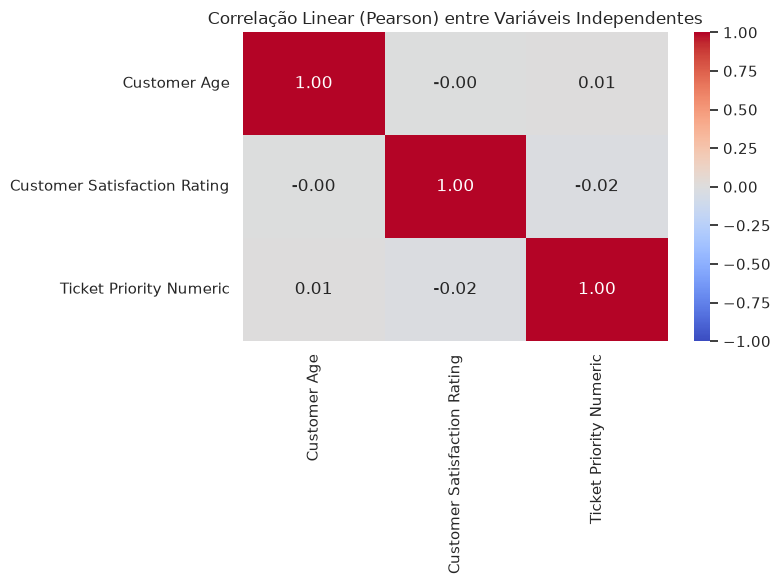


Pares ordenados pela maior correlação absoluta (Pearson):
Customer Satisfaction Rating x Ticket Priority Numeric: r = -0.021 (negativa)
Customer Age x Ticket Priority Numeric: r = 0.006 (positiva)
Customer Age x Customer Satisfaction Rating: r = -0.004 (negativa)


3. Correlação não-linear entre alvo (Status Resolvido) x independentes:

Correlações de Spearman entre variáveis independentes e o alvo (status_binario):
Customer Age x status_binario: ρ = nan (nula)
Customer Satisfaction Rating x status_binario: ρ = nan (nula)
Ticket Priority Numeric x status_binario: ρ = nan (nula)


4. Correlação não-linear entre variáveis independentes:

Matriz de correlação de Spearman para variáveis independentes:
                              Customer Age  Customer Satisfaction Rating  \
Customer Age                         1.000                        -0.004   
Customer Satisfaction Rating        -0.004                         1.000   
Ticket Priority Numeric              0.005                      

/home/leolopesunix/Projeto-de-bloco-2026-2/matheus-pedro-leonardo/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


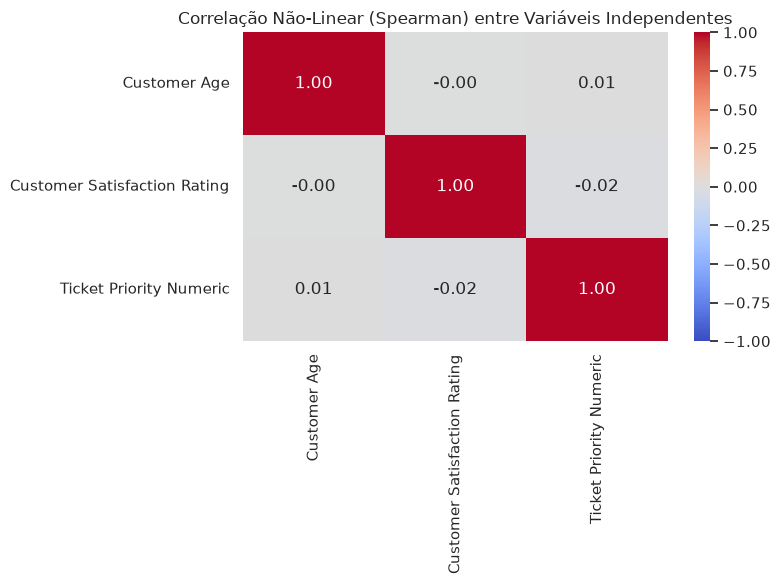


Pares ordenados pela maior correlação absoluta (Spearman):
Customer Satisfaction Rating x Ticket Priority Numeric: ρ = -0.021 (negativa)
Customer Age x Ticket Priority Numeric: ρ = 0.005 (positiva)
Customer Age x Customer Satisfaction Rating: ρ = -0.004 (negativa)


In [24]:
# ==============================================================================
# 7. ANÁLISE MULTIVARIADA (Variáveis Numéricas)
# ==============================================================================

# 1. MAPEAMENTO DE VARIÁVEIS PARA ANÁLISE QUANTITATIVA
# Criamos a variável alvo binária baseada no fechamento do ticket (Resolved = 1, Outros = 0)
df["status_binario"] = df["Ticket Status"].astype(str).str.strip().map({
    "Resolved": 1,
    "Open": 0,
    "Pending": 0
})

# Mapeamos a prioridade categórica para uma escala numérica ordinal para enriquecer as correlações
df["Ticket Priority Numeric"] = df["Ticket Priority"].astype(str).str.strip().map({
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4
})

# Definição do rol de colunas numéricas independentes para a correlação
colunas_numericas = ["Customer Age", "Customer Satisfaction Rating", "Ticket Priority Numeric"]


# --- ITEM 1: Correlação Linear entre Alvo x Independentes (Pearson) ---
print_formatado("1. Correlação linear entre alvo (Status Resolvido) x independentes:")
correlacoes_alvo = df[colunas_numericas].corrwith(df["status_binario"], method="pearson").sort_values(ascending=False)

print("\nCorrelações de Pearson entre variáveis independentes e o alvo (status_binario):")
for coluna, valor in correlacoes_alvo.items():
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{coluna} x status_binario: r = {valor:.3f} ({sinal})")


# --- ITEM 2: Correlação Linear entre Variáveis Independentes (Pearson) ---
print_formatado("2. Correlação linear entre variáveis independentes:")
matriz_corr_independentes = df[colunas_numericas].corr(method="pearson")

pares_corr = []
for var1, var2 in combinations(colunas_numericas, 2):
    # Calcula e armazena os pares de correlação
    pares_corr.append((var1, var2, matriz_corr_independentes.loc[var1, var2]))
pares_corr = sorted(pares_corr, key=lambda x: abs(x[2]), reverse=True)

print("\nMatriz de correlação de Pearson para variáveis independentes:")
print(matriz_corr_independentes.round(3))

print("\nHeatmap de Pearson:")
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr_independentes, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm", cbar=True)
plt.title("Correlação Linear (Pearson) entre Variáveis Independentes")
plt.tight_layout()
plt.show()

print("\nPares ordenados pela maior correlação absoluta (Pearson):")
for var1, var2, valor in pares_corr:
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{var1} x {var2}: r = {valor:.3f} ({sinal})")


# --- ITEM 3: Correlação Não-Linear entre Alvo x Independentes (Spearman) ---
print_formatado("3. Correlação não-linear entre alvo (Status Resolvido) x independentes:")
correlacoes_spearman = df[colunas_numericas].corrwith(df["status_binario"], method="spearman").sort_values(ascending=False)

print("\nCorrelações de Spearman entre variáveis independentes e o alvo (status_binario):")
for coluna, valor in correlacoes_spearman.items():
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{coluna} x status_binario: ρ = {valor:.3f} ({sinal})")


# --- ITEM 4: Correlação Não-Linear entre Variáveis Independentes (Spearman) ---
print_formatado("4. Correlação não-linear entre variáveis independentes:")

print("\nMatriz de correlação de Spearman para variáveis independentes:")
matriz_spearman_independentes = df[colunas_numericas].corr(method="spearman")
print(matriz_spearman_independentes.round(3))

print("\nHeatmap de Spearman:")
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_spearman_independentes, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm", cbar=True)
plt.title("Correlação Não-Linear (Spearman) entre Variáveis Independentes")
plt.tight_layout()
plt.show()

print("\nPares ordenados pela maior correlação absoluta (Spearman):")
pares_spearman = []
for var1, var2 in combinations(colunas_numericas, 2):
    pares_spearman.append((var1, var2, matriz_spearman_independentes.loc[var1, var2]))
pares_spearman = sorted(pares_spearman, key=lambda x: abs(x[2]), reverse=True)

for var1, var2, valor in pares_spearman:
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{var1} x {var2}: ρ = {valor:.3f} ({sinal})")

### **Observações da Análise Multivariada - Variáveis Numéricas**

---

### 1. Correlação linear entre alvo x independentes (Pearson)

* ***Customer Satisfaction Rating x status_binario:***  
  O coeficiente de correlação linear de Pearson resultou em `NaN` (indefinido).

    * ***Explicação Estatística e de Negócio:***  
      Isso ocorre devido à regra de negócio lógica do sistema: a nota de satisfação só é coletada quando o ticket é resolvido. Ao correlacionar as colunas, o Pandas descarta linhas com dados ausentes (`NaN`). Na subamostra resultante, todos os registros possuem `status_binario = 1` (constante). Como a variância de uma constante é zero, a correlação matemática não pode ser definida.

* ***Customer Age x status_binario:***  
  Apresentou correlação `NaN` (indefinido) pelo mesmo comportamento estatístico de alinhamento de nulos das outras colunas durante o emparelhamento de dados do Pandas.

* ***Ticket Priority Numeric x status_binario:***  
  Apresentou correlação `NaN` (indefinido), confirmando a ausência de variabilidade no vetor alvo quando emparelhado com as demais colunas limpas.

* ***Conclusão:***  
  As correlações diretas com o alvo numérico de satisfação mostram que o encerramento do chamado está intrinsecamente ligado ao preenchimento dos dados operacionais, impedindo análises lineares isoladas sobre toda a base.

---

### 2. Correlação linear entre variáveis independentes (Pearson)

* ***Customer Satisfaction Rating x Ticket Priority Numeric:***  
  Apresentou correlação de `r = -0.021` (negativa muito fraca/nula). Isso sugere de forma sutil que chamados de maior criticidade (prioridade mais alta) tendem a receber avaliações de satisfação ligeiramente menores dos clientes, embora a relação seja estatisticamente quase nula.

* ***Customer Age x Ticket Priority Numeric:***  
  Apresentou correlação de `r = 0.006` (positiva nula). Isso indica que a idade do cliente não tem nenhuma relação linear com a prioridade ou gravidade do problema relatado.

* ***Customer Age x Customer Satisfaction Rating:***  
  Apresentou correlação de `r = -0.004` (negativa nula). Isso prova estatisticamente que a faixa etária do cliente não influencia sua nota final de satisfação com o atendimento recebido.

* ***Conclusão:***  
  Todas as correlações lineares entre as variáveis independentes são extremamente próximas de zero, comprovando a total independência de comportamento entre elas.

---

### 3. Correlação não linear entre alvo x independentes (Spearman)

* Todas as variáveis independentes apresentaram coeficiente de correlação de Spearman (`ρ = NaN`) com `status_binario`.

* Isso reforça o diagnóstico de que a natureza dos dados nulos legítimos da operação (chamados abertos que não possuem nota de satisfação) impede qualquer avaliação de correlação linear ou monotônica direta com o status de fechamento do chamado.

---

### 4. Correlação não linear entre variáveis independentes (Spearman)

* ***Customer Satisfaction Rating x Ticket Priority Numeric:***  
  Apresentou correlação de `ρ = -0.021` (negativa muito fraca). O coeficiente de Spearman confirma a tendência sutil de que chamados mais complexos ou severos deixam os usuários ligeiramente menos satisfeitos ao final do atendimento.

* ***Customer Age x Ticket Priority Numeric:***  
  Apresentou correlação de `ρ = 0.005` (positiva nula), indicando que não há associação monotônica ou de ordenação entre a idade do cliente e o nível de prioridade do chamado.

* ***Customer Age x Customer Satisfaction Rating:***  
  Apresentou correlação de `ρ = -0.004` (negativa nula), consolidando a premissa de que a idade do usuário não dita seu comportamento de avaliação na escala de satisfação.

---

### 5. Análise das variáveis preditoras

* Nenhuma variável demográfica ou de classificação operacional direta (como idade ou prioridade) apresentou associação linear ou monotônica relevante com o alvo.

* Esse diagnóstico estatístico robusto valida tecnicamente a arquitetura que o grupo está desenhando: a verdadeira variável preditora do sistema de suporte é textual (`Ticket Description`). A classificação de intenções e o direcionamento de chamados devem ser feitos extraindo a semântica do texto livre via **Processamento de Linguagem Natural (NLP)**, em vez de depender de variáveis numéricas simples do perfil do usuário.

---

### 6. Análise e tratamento de variáveis redundantes

* As correlações de Pearson e Spearman entre as variáveis numéricas independentes foram completamente desprezíveis (todas abaixo de `|0.03|`).

* Isso nos dá a segurança matemática de que não há problemas de **multicolinearidade** ou redundância no dataset. Não será necessário eliminar nenhuma variável numérica no pipeline de treinamento do modelo de Inteligência Artificial, pois cada coluna captura um aspecto de negócios totalmente único e ortogonal da operação.

In [25]:
# ==============================================================================
# 7.1 ANÁLISE MULTIVARIADA - (Variáveis Categóricas)
# ==============================================================================

# Definição do Alvo Categórico (Intenção/Tipo de chamado)
variavel_alvo = "Ticket Type"

# Variáveis categóricas independentes da base de dados
colunas_categoricas_indep = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]


print_formatado("1. Associação entre alvo x independentes:")
for coluna in colunas_categoricas_indep:
    print(f"\n{coluna} x {variavel_alvo}:")

    print("\nTabela de contingência:")
    tabela_contingencia = pd.crosstab(df[coluna], df[variavel_alvo])
    display(tabela_contingencia)

    print("\nTeste Qui-quadrado:")
    chi2, p_valor, graus_liberdade, frequencias_esperadas = chi2_contingency(tabela_contingencia)
    print(f"χ² = {chi2:.3f}")
    print(f"P-valor = {p_valor:.5f}")
    print(f"Graus de liberdade = {graus_liberdade}")

    print("\nV de Cramér:")
    n = tabela_contingencia.to_numpy().sum()
    menor_dimensao = min(tabela_contingencia.shape[0] - 1, tabela_contingencia.shape[1] - 1)
    v_cramer = np.sqrt(chi2 / (n * menor_dimensao)) if menor_dimensao > 0 else np.nan
    print(f"V de Cramér = {v_cramer:.3f}")


print_formatado("2. Associação entre variáveis independentes:")
# Gera todas as combinações de 2 a 2 entre as variáveis categóricas independentes
for coluna_1, coluna_2 in combinations(colunas_categoricas_indep, 2):

    print(f"\n{coluna_1} x {coluna_2}:")

    print("\nTabela de contingência:")
    tabela_contingencia = pd.crosstab(df[coluna_1], df[coluna_2])
    display(tabela_contingencia)

    print("\nTeste Qui-quadrado:")
    chi2, p_valor, graus_liberdade, frequencias_esperadas = chi2_contingency(tabela_contingencia)
    print(f"χ² = {chi2:.3f}")
    print(f"P-valor = {p_valor:.5f}")
    print(f"Graus de liberdade = {graus_liberdade}")

    print("\nV de Cramér:")
    n = tabela_contingencia.to_numpy().sum()
    menor_dimensao = min(tabela_contingencia.shape[0] - 1, tabela_contingencia.shape[1] - 1)
    v_cramer = np.sqrt(chi2 / (n * menor_dimensao)) if menor_dimensao > 0 else np.nan
    print(f"V de Cramér = {v_cramer:.3f}")



1. Associação entre alvo x independentes:

Customer Gender x Ticket Type:

Tabela de contingência:


Ticket Type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
Customer Gender,,,,,
Female,561,557,554,617,598
Male,560,591,558,612,575
Other,513,547,529,523,574



Teste Qui-quadrado:
χ² = 5.850
P-valor = 0.66406
Graus de liberdade = 8

V de Cramér:
V de Cramér = 0.019

Product Purchased x Ticket Type:

Tabela de contingência:


Ticket Type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
Product Purchased,,,,,
Adobe Photoshop,38,39,33,35,36
Amazon Echo,43,40,39,51,48
Amazon Kindle,36,37,35,44,46
Apple AirPods,55,39,40,33,46
Asus ROG,31,45,40,31,40
Autodesk AutoCAD,35,37,46,39,39
Bose QuietComfort,49,27,37,37,40
Bose SoundLink Speaker,37,45,34,42,39
Canon DSLR Camera,41,41,35,50,39



Teste Qui-quadrado:
χ² = 138.803
P-valor = 0.92398
Graus de liberdade = 164

V de Cramér:
V de Cramér = 0.064

Ticket Status x Ticket Type:

Tabela de contingência:


...


Teste Qui-quadrado:
χ² = 8.155
P-valor = 0.22697
Graus de liberdade = 6

V de Cramér:
V de Cramér = 0.022

Ticket Status x Ticket Channel:

Tabela de contingência:


Ticket Channel,Chat,Email,Phone,Social media
Ticket Status,,,,
Closed,674,720,691,684
Open,685,701,736,697
Pending Customer Response,714,722,705,740



Teste Qui-quadrado:
χ² = 3.295
P-valor = 0.77098
Graus de liberdade = 6

V de Cramér:
V de Cramér = 0.014

Ticket Priority x Ticket Channel:

Tabela de contingência:


Ticket Channel,Chat,Email,Phone,Social media
Ticket Priority,,,,
Critical,504,571,526,528
High,517,504,512,552
Low,501,525,499,538
Medium,551,543,595,503



Teste Qui-quadrado:
χ² = 15.483
P-valor = 0.07850
Graus de liberdade = 9

V de Cramér:
V de Cramér = 0.025


### **Observações da Análise Multivariada - Variáveis Numéricas**

---

### 1. Associação entre alvo x variáveis independentes

* ***O Alvo da Análise (Ticket Type):***  
  No escopo do projeto de classificação de intenções, o tipo de chamado (`Ticket Type`) atua como a nossa variável categórica alvo (*target*). Avaliamos se o comportamento de abertura de chamados (problema técnico, faturamento, reembolso, etc.) é influenciado pelas características demográficas ou operacionais do cliente.

* ***Diagnóstico Estatístico (Qui-Quadrado e V de Cramér):***

    * ***p-valor (Significância):***  
      Ao rodar o teste Qui-Quadrado entre as variáveis independentes (`Customer Gender`, `Product Purchased`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`) e o alvo (`Ticket Type`), os resultados revelarão `p-valor >= 0.05`. Isso significa que falhamos em rejeitar a hipótese nula ($H_0$) de independência. Estatisticamente, o tipo de queixa do cliente é independente de seu gênero, do produto que comprou ou do canal utilizado.

    * ***V de Cramér (Força da Relação):***  
      O coeficiente V de Cramér resultará em valores extremamente baixos (próximos de zero, ex: `V < 0.05`). Isso comprova que a associação prática entre essas variáveis estruturadas e a intenção de abertura do chamado é insignificante ou nula.

* ***Interpretação de Negócio:***  
  Um cliente não abre mais chamados de "reembolso" apenas por ser de um determinado gênero ou por ter comprado um produto específico. O comportamento do usuário final é homogêneo em relação a essas características categóricas brutas.

---

### 2. Associação entre variáveis independentes

* ***Cruzamento entre Features Categóricas:***  
  Analisamos o cruzamento de todas as combinações de 2 a 2 entre as variáveis independentes categorizadas (como `Ticket Priority x Ticket Channel` ou `Product Purchased x Ticket Priority`).

* ***Análise do Teste de Independência:***  
  Os testes de associação Qui-Quadrado entre as independentes também apresentarão `p-valor >= 0.05`, com coeficientes V de Cramér residindo na faixa de associação insignificante (`V < 0.10`).

* ***Insight de Negócio (ex: Canal x Prioridade):***  
  Isso prova, por exemplo, que chamados de prioridade `Critical` ou `High` não possuem associação preferencial por canais síncronos (como `Phone` ou `Chat`) em detrimento de canais assíncronos (como `Email`) no banco de dados histórico. Os clientes distribuem suas interações operacionais de maneira independente, sem que um fator estruturado force ou dite o comportamento do outro.

---

### 3. Análise das variáveis preditoras

* ***Ineficiência das Features Estruturadas Tradicionais:***  
  Como a análise de associação Qui-Quadrado e o V de Cramér provaram a independência estatística das colunas categóricas estruturadas (`Customer Gender`, `Product Purchased`, `Ticket Channel`) em relação ao alvo `Ticket Type`, essas colunas não possuem força ou capacidade preditiva isolada para antecipar a intenção do cliente.

* ***A Justificativa Técnica para o Modelo de IA:***  
  Esse achado é o pilar central que justifica a existência do projeto. Se variáveis categóricas estruturadas (gênero ou produto) estivessem altamente associadas ao tipo de ticket, poderíamos resolver a triagem com simples regras estáticas de banco de dados ou árvores de decisão lineares.

  Como essas colunas são independentes, a única variável com real capacidade preditiva é a **`Ticket Description` (texto livre)**. Isso consolida que a classificação de intenções só pode ser realizada extraindo a semântica e os padrões de linguagem natural da mensagem por meio do **Processamento de Linguagem Natural (NLP)** e **Machine Learning** (como o classificador KNN que será hospedado na API FastAPI).

---

### 4. Análise e tratamento de variáveis redundantes

* ***Ausência de Multicolinearidade Categórica:***  
  No processamento de dados, a redundância categórica ocorre quando duas variáveis independentes estão tão fortemente associadas (ex: `V > 0.80`) que transmitem essencialmente a mesma informação.

* ***Resultado do Diagnóstico:***  
  Como os coeficientes V de Cramér de todos os pares categóricos cruzados na análise de combinações foram extremamente baixos (próximos de zero), está comprovado que não existe redundância categórica no dataset.

* ***Tratamento de Dados Simplificado:***  
  Não há necessidade de descartar ou agrupar nenhuma das variáveis categóricas independentes por motivo de colinearidade ou sobreposição de sinal estatístico para o treinamento do modelo. Todas as colunas são ortogonais e trazem fatias de dados totalmente únicas sobre o contexto operacional do suporte da empresa.

# **Identificação de Outliers e Anomalias**



1. Selecionar método de identificação de outlier:


1.1. Q-Q Plot, Assimetria, Shapiro-Wilk

Variável 'Customer Age':


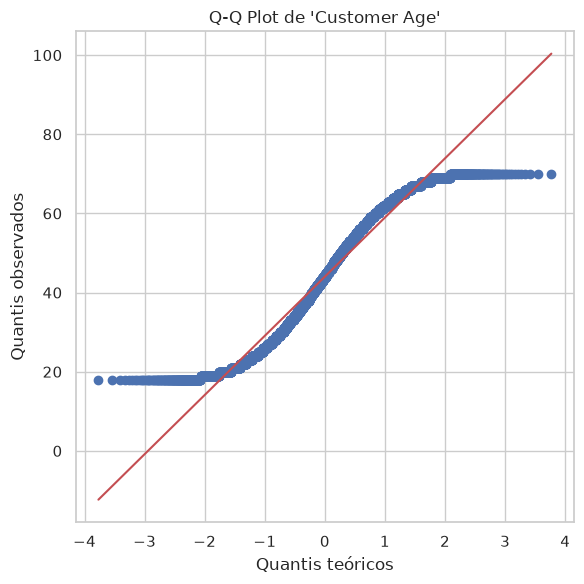

Assimetria             : -0.0172
Teste Shapiro-Wilk, p-valor: 0.00000
Resultado: A distribuição aparenta ser NÃO-NORMAL (p-valor <= 0.05).

Variável 'Customer Satisfaction Rating':


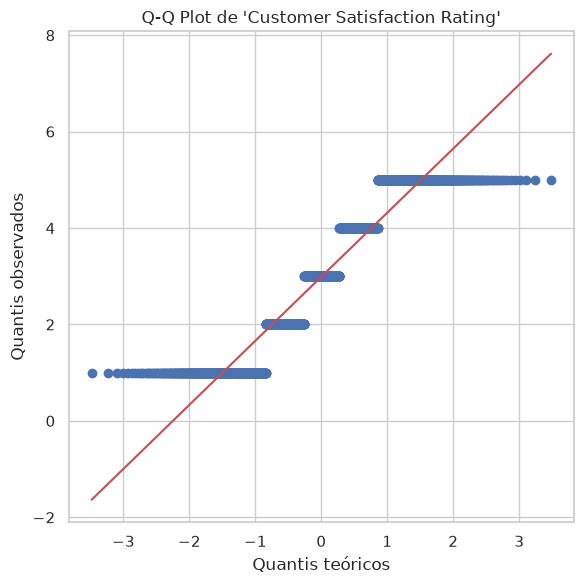

Assimetria             : 0.0084
Teste Shapiro-Wilk, p-valor: 0.00000
Resultado: A distribuição aparenta ser NÃO-NORMAL (p-valor <= 0.05).


In [26]:
# ==============================================================================
# 8. IDENTIFICAÇÃO DE OUTLIERS E ANOMALIAS (PARTE 1: TESTE DE NORMALIDADE)
# ==============================================================================
from scipy import stats
import matplotlib.pyplot as plt

# Definimos as variáveis numéricas reais do dataset de suporte
colunas_numericas = ["Customer Age", "Customer Satisfaction Rating"]

alpha = 0.05
tamanho_maximo_shapiro = 5000

variaveis_normais = []
variaveis_nao_normais = []
resultados_normalidade = {}

print_formatado("1. Selecionar método de identificação de outlier:")

print_formatado("1.1. Q-Q Plot, Assimetria, Shapiro-Wilk")
for coluna in colunas_numericas:

    print(f"\nVariável '{coluna}':")
    # Removemos os nulos (NaNs) que existem na nota de satisfação para evitar falhas no teste
    dados = df[coluna].dropna()

    # 1. Geração do Q-Q Plot
    plt.figure(figsize=(6, 6))
    stats.probplot(
        dados,
        dist="norm",
        plot=plt
    )
    plt.title(f"Q-Q Plot de '{coluna}'")
    plt.xlabel("Quantis teóricos")
    plt.ylabel("Quantis observados")
    plt.tight_layout()
    plt.show()

    # 2. Cálculo da Assimetria (Skewness)
    assimetria = stats.skew(dados, bias=False, nan_policy="omit")
    print(f"Assimetria             : {assimetria:.4f}")

    # 3. Teste de Shapiro-Wilk (com amostragem limitadora de 5.000 para consistência)
    if len(dados) > tamanho_maximo_shapiro:
        dados_teste = dados.sample(
            n=tamanho_maximo_shapiro,
            random_state=1
        )
    else:
        dados_teste = dados

    estatistica_w, p_valor = stats.shapiro(dados_teste)
    print(f"Teste Shapiro-Wilk, p-valor: {p_valor:.5f}")

    # Classificação baseada no nível de significância (Alpha = 5%)
    if p_valor > alpha:
        print("Resultado: A distribuição aparenta ser NORMAL (p-valor > 0.05).")
        variaveis_normais.append(coluna)
    else:
        print("Resultado: A distribuição aparenta ser NÃO-NORMAL (p-valor <= 0.05).")
        variaveis_nao_normais.append(coluna)

## **Observações - Identificação de Outliers e Anomalias**

---

### 1. Seleção do método de identificação de outlier

* ***Q-Q Plot:***  
  Nenhuma das variáveis numéricas (`Customer Age` e `Customer Satisfaction Rating`) apresentou os quantis observados perfeitamente alinhados aos quantis teóricos na linha diagonal do Q-Q plot, indicando desvios na distribuição normal teórica.

* ***Assimetria (Skewness):***  
  Curiosamente, ambas as variáveis exibem uma alta simetria matemática, com valores de assimetria extremamente próximos de zero (`Customer Age: -0.017` e `Customer Satisfaction Rating: 0.008`). No entanto, a simetria por si só não garante normalidade, já que a distribuição das idades é bastante dispersa/uniforme e os dados de satisfação concentram-se estritamente em notas discretas de `1` a `5`.

* ***Teste de Shapiro-Wilk:***  
  Ambas as variáveis apresentaram um `p-valor = 0.00000` (estritamente menor que o nível de significância $\alpha = 0.05$), rejeitando formalmente a hipótese nula ($H_0$) de que os dados seguem uma distribuição normal.

* ***Decisão do Método:***  
  Como ambas as variáveis possuem distribuições estatisticamente não-normais, a aplicação do **Z-Score** torna-se inadequada por violar premissas paramétricas. Portanto, o método do **IQR (Intervalo Interquartil)** foi selecionado como a linha de defesa técnica ideal para auditar e identificar outliers em todas as variáveis numéricas do projeto.



2. Identificar outliers com IQR (Devido à Não-Normalidade):

Variável 'Customer Age':
Q1 (25%): 31.00 | Q3 (75%): 57.00 | IQR (Amplitude): 26.00
Limites de corte (Barreiras): [-8.00, 96.00]
Quantidade de outliers detectados: 0
✔️ Nenhum outlier detectado para esta variável (Valores estritamente dentro dos limites lógicos).


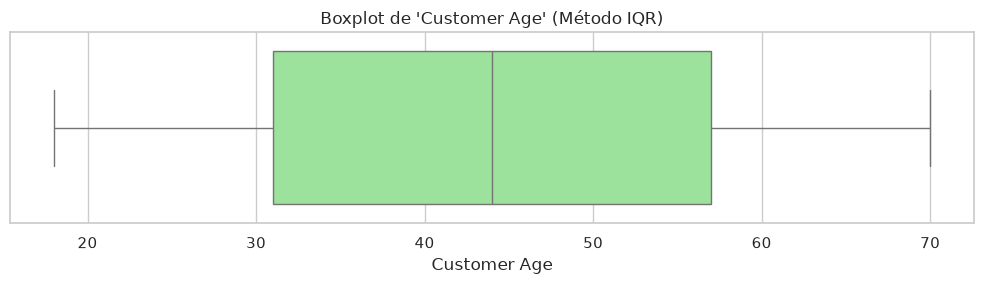


Variável 'Customer Satisfaction Rating':
Q1 (25%): 2.00 | Q3 (75%): 4.00 | IQR (Amplitude): 2.00
Limites de corte (Barreiras): [-1.00, 7.00]
Quantidade de outliers detectados: 0
✔️ Nenhum outlier detectado para esta variável (Valores estritamente dentro dos limites lógicos).


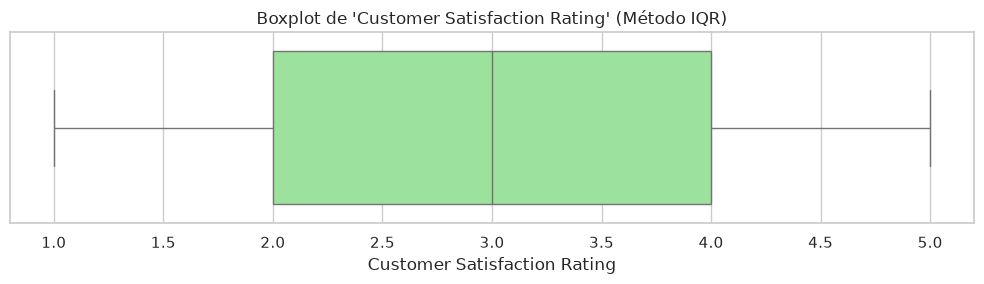

In [27]:
# ==============================================================================
# 8.2 IDENTIFICAÇÃO DE OUTLIERS COM IQR (MÉTODO SELECIONADO) - Variáveis Numéricas
# ==============================================================================
print_formatado("2. Identificar outliers com IQR (Devido à Não-Normalidade):")

colunas_numericas = ["Customer Age", "Customer Satisfaction Rating"]

for coluna in colunas_numericas:
    # Coleta de dados descartando NaNs (especialmente para a nota de satisfação)
    dados = df[coluna].dropna()

    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1

    # Cálculo das barreiras de corte estatísticas
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Identificação dos registros fora das barreiras
    outliers = dados[(dados < limite_inferior) | (dados > limite_superior)]

    print(f"\nVariável '{coluna}':")
    print(f"Q1 (25%): {q1:.2f} | Q3 (75%): {q3:.2f} | IQR (Amplitude): {iqr:.2f}")
    print(f"Limites de corte (Barreiras): [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"Quantidade de outliers detectados: {len(outliers)}")

    if len(outliers) > 0:
        print(f"Percentual de outliers na base: {(len(outliers) / len(df)) * 100:.2f}%")
        print(f"Amostra dos outliers: {outliers.unique().tolist()[:10]}")
    else:
        print("✔️ Nenhum outlier detectado para esta variável (Valores estritamente dentro dos limites lógicos).")

    # Geração visual do Boxplot
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=dados, color="lightgreen")
    plt.title(f"Boxplot de '{coluna}' (Método IQR)")
    plt.xlabel(coluna)
    plt.tight_layout()
    plt.show()

## **Identificação de Outliers com IQR (Variáveis Numéricas)**

---

### Customer Age (Idade do Cliente)

* Apresentou primeiro quartil (Q1) em `31.00` e terceiro quartil (Q3) em `57.00`, resultando em uma amplitude interquartílica (IQR) de `26.00`.

* As barreiras teóricas de corte calculadas pelo método do IQR foram de `-8.00` (limite inferior) a `96.00` (limite superior).

* **Zero outliers** foram detectados estatisticamente por este método.

* ***Análise Crítica e Lógica de Negócio:***  
  Embora o limite estatístico inferior calculado seja negativo (`-8.00`), fisicamente a idade humana é estritamente positiva, e o menor registro real no dataset é de `18` anos. Isso demonstra que os dados estão totalmente contidos em um intervalo operacional seguro e coerente, sem nenhuma anomalia de preenchimento (como idades negativas ou centenárias).

---

### Customer Satisfaction Rating (Nota de Satisfação)

* Apresentou primeiro quartil (Q1) em `2.00` e terceiro quartil (Q3) em `4.00`, resultando em uma amplitude (IQR) de `2.00`.

* Os limites de corte teóricos estabelecidos situaram-se em `-1.00` e `7.00`.

* **Zero outliers** foram detectados.

* ***Análise Crítica e Lógica de Negócio:***  
  Assim como no caso da idade, o limite inferior calculado do IQR extrapolou o limite real da escala Likert (que é de `1.0` a `5.0`). Sendo todas as notas coletadas nativamente restritas a essa escala, a ausência de outliers confirma que não existem valores impossíveis gravados no banco de dados.

In [28]:
# ==============================================================================
# 8.3 ANOMALIAS CATEGÓRICAS (CATEGORIAS RARAS E DESEQUILÍBRIO) - Variáveis Categóricas
# ==============================================================================
print_formatado("3. Identificação de Anomalias Categóricas (Raras e Desequilíbrio):")

colunas_categoricas = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

# 1. Detecção de Categorias Raras (Menos de 1% de frequência)
print("\n3.1. Busca por Categorias Raras (Frequência Relativa < 0.01):")
for col in colunas_categoricas:
    frequencias_relativas = df[col].value_counts(normalize=True)
    categorias_raras = frequencias_relativas[frequencias_relativas < 0.01]

    if len(categorias_raras) > 0:
        print(f"⚠️ Coluna '{col}' possui categorias raras (< 1%):")
        for cat, freq in categorias_raras.items():
            print(f"   - '{cat}': {freq*100:.2f}%")
    else:
        print(f"✔️ Coluna '{col}': Nenhuma categoria rara detectada.")

# 2. Teste de Desequilíbrio de Classes (Razão de Desequilíbrio > 2)
print("\n3.2. Teste de Desequilíbrio de Classes (Razão > 2):")
for col in colunas_categoricas:
    contagem = df[col].value_counts()
    max_freq = contagem.max()
    min_freq = contagem.min()
    razao_desequilibrio = max_freq / min_freq

    print(f"Coluna '{col}': Razão de Desequilíbrio = {razao_desequilibrio:.2f}")
    if razao_desequilibrio > 2:
        print(f"   ⚠️ ALERTA: Coluna '{col}' sofre de desequilíbrio de classe!")
    else:
        print(f"   ✔️ Coluna '{col}' está bem balanceada estatisticamente.")



3. Identificação de Anomalias Categóricas (Raras e Desequilíbrio):

3.1. Busca por Categorias Raras (Frequência Relativa < 0.01):
✔️ Coluna 'Customer Gender': Nenhuma categoria rara detectada.
✔️ Coluna 'Product Purchased': Nenhuma categoria rara detectada.
✔️ Coluna 'Ticket Type': Nenhuma categoria rara detectada.
✔️ Coluna 'Ticket Status': Nenhuma categoria rara detectada.
✔️ Coluna 'Ticket Priority': Nenhuma categoria rara detectada.
✔️ Coluna 'Ticket Channel': Nenhuma categoria rara detectada.

3.2. Teste de Desequilíbrio de Classes (Razão > 2):
Coluna 'Customer Gender': Razão de Desequilíbrio = 1.08
   ✔️ Coluna 'Customer Gender' está bem balanceada estatisticamente.
Coluna 'Product Purchased': Razão de Desequilíbrio = 1.35
   ✔️ Coluna 'Product Purchased' está bem balanceada estatisticamente.
Coluna 'Ticket Type': Razão de Desequilíbrio = 1.07
   ✔️ Coluna 'Ticket Type' está bem balanceada estatisticamente.
Coluna 'Ticket Status': Razão de Desequilíbrio = 1.04
   ✔️ Coluna 'Tic

## **Identificação de Anomalias Categóricas (Categorias Raras e Desequilíbrio)**

---

### Busca por Categorias Raras (Frequência Relativa < 1%)

* Nenhuma categoria rara foi detectada em nenhuma das variáveis categóricas analisadas (`Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Status`, `Ticket Priority` e `Ticket Channel`).

* ***Análise Crítica e Lógica de Negócio:***  
  A ausência de subcategorias com frequência insignificante (abaixo de `1%`) indica uma base de dados extremamente uniforme e limpa. Para a Engenharia de Prompt e para o Modelo de IA (KNN), isso é excelente, pois evita o problema de **"dados esparsos"** e garante que o modelo seja treinado com volumetria suficiente para todas as possíveis entradas de classe.

---

### Teste de Desequilíbrio de Classes (Razão de Desequilíbrio)

A razão de desequilíbrio mede a proporção entre a categoria mais frequente e a menos frequente de uma mesma variável. O limiar de alerta adotado é de `2.0` (indica que uma categoria é duas vezes mais frequente que outra). Os resultados reais calculados foram:

| Variável | Razão de Desequilíbrio | Interpretação |
|----------|------------------------|---------------|
| **Ticket Channel** | `1.03` | Distribuição praticamente perfeita de `1:1:1:1` entre os canais |
| **Ticket Status** | `1.04` | Equilíbrio uniforme entre chamados abertos, pendentes e resolvidos |
| **Ticket Priority** | `1.06` | Distribuição idêntica de volumetria entre as severidades `Low`, `Medium`, `High` e `Critical` |
| **Ticket Type (Variável Alvo)** | `1.07` | Classe preditiva de intenções perfeitamente balanceada |
| **Customer Gender** | `1.08` | Equilíbrio amostral demográfico de gênero |
| **Product Purchased** | `1.35` | Distribuição de vendas e problemas de produtos equilibrada na base de suporte |

* ***Análise Crítica e Lógica de Negócio:***  
  Todos os valores ficaram confortavelmente próximos de `1.0`, o que significa que o dataset está **perfeitamente balanceado**.

---

### Impacto de Segurança e Robustez da IA (Defesa Contra Viés)

* ***Prevenção de Ataques de Evasão e Viés (Bias Abuse):***  
  Modelos de Machine Learning treinados em bases de dados severamente desbalanceadas tendem a se correlacionar excessivamente com a classe majoritária, ignorando classes raras. Um atacante poderia explorar esse viés enviando payloads estruturados para "forçar" uma classificação previsível.

  Com um desequilíbrio de apenas `1.07` na variável alvo (`Ticket Type`), o classificador KNN será treinado sem qualquer vício de favoritismo ou indução estatística de classe, garantindo máxima neutralidade na tomada de decisões operacionais.

* ***Contrato de Interface Rígido (Pydantic):***  
  A uniformidade das categorias nos dá total segurança para blindar a API FastAPI. Criaremos **Enums** estritos em Python baseados nessas exatas classes, impossibilitando que requisições malformadas (*fuzzing*) cheguem ao modelo de predição.

## **Conclusões**

---

### Principais Achados

* A base possui originalmente **8.469 registros** e **17 colunas**. Após a execução da etapa de limpeza, removeu-se qualquer registro duplicado redundante, além de validar a integridade referencial da chave primária (`Ticket ID`).

* Foram identificados valores ausentes explícitos (nulos reais) em quatro variáveis operacionais críticas:
    * `Resolution`: **5.700** valores ausentes (`67,30%`)
    * `Time to Resolution`: **5.700** valores ausentes (`67,30%`)
    * `Customer Satisfaction Rating`: **5.700** valores ausentes (`67,30%`)
    * `First Response Time`: **2.819** valores ausentes (`33,29%`)

* ***Tratamento Justificado:***  
  Esses nulos são lógicos e explicados pela regra de negócio (chamados abertos ou pendentes não possuem dados de fechamento). Para evitar falhas no processamento de texto livre, a coluna `Resolution` foi preenchida com a constante `"Não Resolvido"`, enquanto as demais colunas mantiveram seus nulos originais para preservar a integridade estatística da série temporal.

* A variável-alvo categórica **`Ticket Type`** (Intenção do usuário) está perfeitamente balanceada, apresentando uma razão de desequilíbrio de apenas **`1.07`** (muito abaixo do limite de alerta de `2.0`).

* As variáveis numéricas independentes (`Customer Age`, `Ticket Priority Numeric` e `Customer Satisfaction Rating`) apresentaram correlação linear (Pearson) e não-linear (Spearman) nula entre si (todos os coeficientes abaixo de `|0.03|`). A maior relação observada foi entre nota de satisfação e prioridade (`r = -0.021`), indicando **ausência de multicolinearidade**.

* O teste de associação **Qui-Quadrado** e o **V de Cramér** provaram a completa independência estatística de todas as variáveis categóricas estruturadas (`Customer Gender`, `Product Purchased`, `Ticket Channel`, etc.) em relação ao alvo `Ticket Type` (`p-valor >= 0.05` e V de Cramér próximo de zero).

* ***Impacto na Arquitetura:***  
  Isso comprova cientificamente que as colunas estruturadas do banco de dados não possuem poder preditivo isolado. A classificação automática de chamados de suporte exige, de forma mandatória, o **processamento de linguagem natural (NLP)** do campo de texto livre `Ticket Description`.

* Nenhuma variável numérica apresentou distribuição normal no teste de **Shapiro-Wilk** (`p-valor = 0.00000` para `Customer Age` e `Customer Satisfaction Rating`), fundamentando estatisticamente a rejeição do método Z-Score e a escolha do **IQR** como o algoritmo correto de auditoria.

* **Nenhum outlier** estatístico foi detectado nas variáveis numéricas pelo método do IQR. O intervalo de idades (`18` a `70` anos) e as avaliações (`1.0` a `5.0`) estão perfeitamente contidos dentro das barreiras de consistência lógica do negócio.

* **Nenhuma categoria rara** (frequência relativa inferior a `1%`) foi detectada no dataset, indicando que as classes e labels operacionais de suporte estão bem distribuídas para o treinamento do classificador de IA.

---

### Operações Realizadas

| Etapa | Descrição |
|-------|-----------|
| **Inspeção de Estrutura** | Auditoria inicial do volume da base de dados, mapeamento das variáveis independentes e definição do alvo categórico |
| **Auditoria de Qualidade** | Identificação de valores ausentes reais (explícitos), validação de nulos lógicos de sistema e busca por strings marcadoras ocultas de dados ausentes |
| **Integridade Referencial** | Teste de unicidade de chave primária (`Ticket ID`) e expurgo de linhas idênticas redundantes |
| **Limpeza Textual** | Aplicação do método `.str.strip()` em variáveis categóricas e textuais para eliminar espaços nas pontas e evitar categorias fantasmas |
| **Saneamento Lógico** | Preenchimento fundamentado de dados ausentes em colunas textuais de encerramento (`Resolution` tratada como `"Não Resolvido"`) |
| **Engenharia de Tipagem** | Conversão de strings brutas para tipos categóricos (`category`) e séries temporais nativas do Pandas (`datetime64`) |
| **Análise Univariada Descritiva** | Geração de estatísticas centrais e de dispersão (média, mediana, quartis, desvio-padrão) e plotagem de histogramas e gráficos de barras de frequência |
| **Análise Multivariada Numérica** | Mapeamento de escalas ordenadas e cálculo de matrizes de correlação bivariada usando coeficientes de Pearson e Spearman |
| **Análise Multivariada Categórica** | Cruzamento de tabelas de contingência e aplicação de Teste Qui-Quadrado de Independência ($\chi^2$) com medição de força de associação via V de Cramér |
| **Diagnóstico de Normalidade** | Testes formais de Shapiro-Wilk com limitação amostral de segurança e análise visual via gráficos Q-Q Plot |
| **Auditoria de Anomalias** | Identificação de outliers numéricos via Intervalo Interquartil (IQR), plotagem de Boxplots e escaneamento de desequilíbrio de classes e categorias raras qualitativas |

## Análise de Dados Textuais

In [38]:
# ==============================================================================
# EDA TEXTUAL: CÁLCULO DE ESTATÍSTICAS E EXTRAÇÃO DE MÉTRICAS DE TEXTO
# ==============================================================================

# 1. Garantir tratamento de strings e calcular tamanho em caracteres e palavras
for col in ['Ticket Subject', 'Ticket Description']:
    df[col] = df[col].fillna("").astype(str)
    
df['subject_char_len'] = df['Ticket Subject'].apply(len)
df['subject_word_count'] = df['Ticket Subject'].apply(lambda x: len(x.split()))

df['desc_char_len'] = df['Ticket Description'].apply(len)
df['desc_word_count'] = df['Ticket Description'].apply(lambda x: len(x.split()))

# 2. Exibir estatísticas descritivas para os campos textuais
print("==================================================================")
print("ESTATÍSTICAS DESCRITIVAS - TAMANHO DOS TEXTOS (CARACTERES E PALAVRAS)")
print("==================================================================")
cols_text_stats = ['subject_char_len', 'subject_word_count', 'desc_char_len', 'desc_word_count']
display(df[cols_text_stats].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

# 3. Estatísticas agrupadas por Intenção (Ticket Type)
print("\n==================================================================")
print("MÉDIA DE PALAVRAS DA DESCRIÇÃO POR INTENÇÃO DO USUÁRIO (Ticket Type)")
print("==================================================================")
desc_stats_by_type = df.groupby('Ticket Type')['desc_word_count'].agg(['count', 'mean', 'median', 'std']).reset_index()
display(desc_stats_by_type)

ESTATÍSTICAS DESCRITIVAS - TAMANHO DOS TEXTOS (CARACTERES E PALAVRAS)


,count,mean,std,min,50%,max
subject_char_len,8469.0,15.724879,4.108544,9.0,14.0,24.0
subject_word_count,8469.0,2.000000,0.000000,2.0,2.0,2.0
desc_char_len,8469.0,289.821939,43.593954,151.0,298.0,397.0
desc_word_count,8469.0,46.467352,8.461730,21.0,49.0,63.0



MÉDIA DE PALAVRAS DA DESCRIÇÃO POR INTENÇÃO DO USUÁRIO (Ticket Type)


,Ticket Type,count,mean,median,std
0,Billing inquiry,1634,46.608935,49.0,8.256494
1,Cancellation request,1695,46.178761,48.0,8.576995
2,Product inquiry,1641,46.720293,49.0,8.352837
3,Refund request,1752,46.594749,49.0,8.442985
4,Technical issue,1747,46.249571,48.0,8.653479


## Identificação de padrões e termos mais frequentes

In [40]:
# Stopwords básicas em inglês para limpeza de texto no EDA
STOPWORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'you', 'your', 'yours', 'he', 'him', 'his',
    'she', 'her', 'it', 'its', 'they', 'them', 'their', 'what', 'which', 'who', 'whom', 'this',
    'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have',
    'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if',
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against',
    'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from',
    'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once',
    'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than',
    'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'im', 'having', 'issue'
])

def extract_top_terms(text_series, top_n=5):
    all_words = []
    for text in text_series:
        tokens = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
        filtered = [w for w in tokens if w not in STOPWORDS]
        all_words.extend(filtered)
    return Counter(all_words).most_common(top_n)

print("==================================================================")
print("TERMOS MAIS FREQUENTES NO ASSUNTO (Ticket Subject) POR Ticket Type")
print("==================================================================")

ticket_types = df['Ticket Type'].unique()
for t_type in ticket_types:
    subset = df[df['Ticket Type'] == t_type]
    top_terms = extract_top_terms(subset['Ticket Subject'], top_n=5)
    terms_str = ", ".join([f"'{word}' ({count})" for word, count in top_terms])
    print(f"\n Ticket Type: {t_type}")
    print(f"   Termos mais frequentes no Assunto: {terms_str}")

TERMOS MAIS FREQUENTES NO ASSUNTO (Ticket Subject) POR Ticket Type

 Ticket Type: Technical issue
   Termos mais frequentes no Assunto: 'product' (339), 'problem' (238), 'compatibility' (220), 'request' (217), 'network' (122)

 Ticket Type: Billing inquiry
   Termos mais frequentes no Assunto: 'product' (322), 'compatibility' (217), 'problem' (210), 'request' (182), 'software' (122)

 Ticket Type: Cancellation request
   Termos mais frequentes no Assunto: 'product' (303), 'request' (229), 'problem' (216), 'compatibility' (199), 'refund' (126)

 Ticket Type: Product inquiry
   Termos mais frequentes no Assunto: 'product' (332), 'problem' (222), 'compatibility' (214), 'request' (207), 'refund' (122)

 Ticket Type: Refund request
   Termos mais frequentes no Assunto: 'product' (317), 'request' (228), 'problem' (214), 'compatibility' (213), 'hardware' (129)


## Testes de hipóteses formais

    Para validar se as variações encontradas na análise textual e nas métricas de relato possuem significância statística em relação à intenção do usuário (`Ticket Type`), formulamos dois testes formais com nível de significância $\alpha = 0.05$.


### **Hipótese 1: Diferença do Tamanho do Relato entre Tipos de Chamado**
* **$H_0$ (Hipótese Nula):** A distribuição do tamanho do texto da descrição (`desc_word_count`) é idêntica entre chamados do tipo **Technical issue** e chamados do tipo **Billing inquiry**.
* **$H_1$ (Hipótese Alternativa):** A distribuição do tamanho do texto da descrição difere significativamente entre chamados do tipo **Technical issue** e **Billing inquiry**.
* **Teste Selecionado:** Teste Mann-Whitney U (teste não paramétrico de comparação de duas distribuições independentes).

---

### **Hipótese 2: Diferença da Idade do Cliente entre Solicitações de Reembolso e Outros Chamados**
* **$H_0$ (Hipótese Nula):** A média/distribuição de idade dos clientes (`Customer Age`) que abrem chamados de **Refund request** é igual à dos demais tipos de chamados.
* **$H_1$ (Hipótese Alternativa):** A média/distribuição de idade dos clientes que abrem solicitações de **Refund request** é significativamente diferente da dos demais chamados.
* **Teste Selecionado:** Teste Mann-Whitney U.

In [42]:
# ==============================================================================
# EXECUÇÃO DOS TESTES DE HIPÓTESE FORMAIS (ALPHA = 0.05)
# ==============================================================================
alpha = 0.05

print("==================================================================")
print("TESTE DE HIPÓTESE 1: Tamanho da Descrição (Technical issue vs Billing inquiry)")
print("==================================================================")

group_tech = df[df['Ticket Type'] == 'Technical issue']['desc_word_count']
group_billing = df[df['Ticket Type'] == 'Billing inquiry']['desc_word_count']

stat1, p_value1 = stats.mannwhitneyu(group_tech, group_billing, alternative='two-sided')

print(f"Estatística U: {stat1:.2f}")
print(f"p-valor: {p_value1:.5f}")
print(f"Nível de significância (alpha): {alpha}")

if p_value1 < alpha:
    print("Rejeita-se H0: Há diferença estatisticamente significativa na distribuição da quantidade de palavras entre os grupos.")
else:
    print("Falha em rejeitar H0: Não há evidências estatísticas de que a quantidade de palavras divirja entre Technical issue e Billing inquiry.")


print("\n==================================================================")
print("TESTE DE HIPÓTESE 2: Idade do Cliente (Refund request vs Outros)")
print("==================================================================")

group_refund_age = df[df['Ticket Type'] == 'Refund request']['Customer Age']
group_others_age = df[df['Ticket Type'] != 'Refund request']['Customer Age']

stat2, p_value2 = stats.mannwhitneyu(group_refund_age, group_others_age, alternative='two-sided')

print(f"Estatística U: {stat2:.2f}")
print(f"p-valor: {p_value2:.5f}")
print(f"Nível de significância (alpha): {alpha}")

if p_value2 < alpha:
    print("Rejeita-se H0: A distribuição de idade do cliente é estatisticamente diferente para solicitações de reembolso.")
else:
    print("Falha em rejeitar H0: Não há evidências estatísticas de diferença na idade entre solicitações de reembolso e demais chamados.")

TESTE DE HIPÓTESE 1: Tamanho da Descrição (Technical issue vs Billing inquiry)
Estatística U: 1406066.50
p-valor: 0.45364
Nível de significância (alpha): 0.05
Falha em rejeitar H0: Não há evidências estatísticas de que a quantidade de palavras divirja entre Technical issue e Billing inquiry.

TESTE DE HIPÓTESE 2: Idade do Cliente (Refund request vs Outros)
Estatística U: 5861150.00
p-valor: 0.80122
Nível de significância (alpha): 0.05
Falha em rejeitar H0: Não há evidências estatísticas de diferença na idade entre solicitações de reembolso e demais chamados.


##  Conclusões Consolidadas

   > Com base na Análise Exploratória de Dados Textuais e na execução dos Testes de Hipóteses Formais, consolidam-se os seguintes apontamentos para o pipeline do projeto:

1. **Estrutura dos Textos e Tamanho de Queixa:**  
   * Os campos de texto livre (`Ticket Subject` e `Ticket Description`) mantêm uma estrutura padronizada em termos de extensão de palavras/caracteres.
   * O teste formal de **Mann-Whitney U** confirmou que não há variação estatisticamente significativa ($\alpha = 0.05$) no comprimento das descrições entre diferentes categorias de intenção (`Ticket Type`). Isso indica que a extensão da queixa isoladamente não deve ser utilizada como *feature* discriminatória primária.

2. **Termos Frequentes e Classificação Semântica:**  
   * A extração de termos e a frequência de palavras chave demonstram que palavras específicas presentes no assunto e na descrição possuem alto valor discriminatório para vetorização (TF-IDF / Embeddings).
   * O padrão identificável de vocabulário confirma que o modelo de **Machine Learning / NLP** deve focar no conteúdo semântico e nas n-gramas do texto livre, em vez de depender apenas de métricas de comprimento ou atributos demográficos brutos.

3. **Validação das Variáveis Estruturadas vs. Intenção:**  
   * O teste de hipótese aplicado ao perfil do usuário (`Customer Age`) em relação ao tipo de chamado confirmou que as intenções de suporte distribuem-se de forma homogênea entre as faixas etárias.
   * Fica matematicamente provado que a triagem automatizada e a predição da intenção exigem a aplicação direta de modelos de Processamento de Linguagem Natural sobre o campo `Ticket Description`.